# LLM & SLM Memory Footprints — From Bits to Billion Parameters

> **Curriculum Path:** FP32 → FP16 → BF16 → INT8 → INT4 → NF4 → Double Quantization → GGUF/GPTQ/AWQ → Production Recipes

This notebook builds intuition from raw bit-level representation all the way to how frontier models like LLaMA-3, Mistral, Phi-3, and Gemma are compressed and served in practice.

**What you'll master:**
- Byte-level arithmetic for model sizing (the formula every ML engineer must know)
- Why FP32 is being abandoned and what BF16 buys you
- The NF4 insight: information-theoretically optimal for normally distributed weights
- Double quantization — quantizing the quantization constants
- Full memory budget breakdown: weights + optimizer states + activations + KV cache
- A reusable `ModelMemoryCalculator` class you can keep in your toolkit

---
**Dependencies:** `numpy`, `matplotlib` — no ML frameworks needed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import struct
import math
import warnings
warnings.filterwarnings('ignore')

# ── Dark theme consistent with your ML notebook series ──────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0f1117',
    'axes.facecolor':    '#1a1d27',
    'axes.edgecolor':    '#3a3d4d',
    'axes.labelcolor':   '#e0e0e0',
    'axes.titlecolor':   '#ffffff',
    'xtick.color':       '#a0a0b0',
    'ytick.color':       '#a0a0b0',
    'text.color':        '#e0e0e0',
    'grid.color':        '#2a2d3d',
    'grid.linestyle':    '--',
    'grid.alpha':        0.5,
    'font.family':       'monospace',
    'legend.facecolor':  '#1a1d27',
    'legend.edgecolor':  '#3a3d4d',
})

# Palette
C = {
    'fp32':   '#e74c3c',
    'fp16':   '#e67e22',
    'bf16':   '#f1c40f',
    'int8':   '#2ecc71',
    'int4':   '#1abc9c',
    'nf4':    '#3498db',
    'dq':     '#9b59b6',
    'accent': '#00d4ff',
    'dim':    '#4a4d5d',
}

print('✅  Environment ready — let\'s dissect every byte in a language model.')

✅  Environment ready — let's dissect every byte in a language model.


---
## Part 1 — The Fundamental Formula

Before any quantization, one equation governs everything:

$$\text{Memory (bytes)} = N_{\text{params}} \times \frac{\text{bits\_per\_param}}{8}$$

A **7B model in FP32** = 7 × 10⁹ × 4 bytes = **28 GB**. That's why no one runs them in FP32.

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1 · Raw parameter counting and memory arithmetic
# ─────────────────────────────────────────────────────────────────────────────

def params_to_memory(n_params: float, bits: int) -> dict:
    """Convert parameter count to memory in multiple units."""
    bytes_total = n_params * (bits / 8)
    return {
        'bytes': bytes_total,
        'KB':    bytes_total / 1024,
        'MB':    bytes_total / 1024**2,
        'GB':    bytes_total / 1024**3,
    }

# Real models (parameter counts in billions)
models = {
    'Phi-3 Mini (3.8B)':     3.8e9,
    'Mistral 7B':            7.2e9,
    'LLaMA-3 8B':            8.0e9,
    'Gemma 9B':              9.0e9,
    'LLaMA-3 70B':          70.0e9,
    'Mixtral 8×7B':         46.7e9,   # only 13B active per token
    'LLaMA-3 405B':        405.0e9,
    'GPT-4 (est. ~1.7T)': 1700.0e9,
}

dtypes = {'FP32': 32, 'FP16/BF16': 16, 'INT8': 8, 'INT4/NF4': 4}

print(f"{'Model':<28} {'Params':>10} {'FP32 (GB)':>12} {'BF16 (GB)':>12} {'INT8 (GB)':>12} {'NF4 (GB)':>10}")
print('─' * 86)
for name, p in models.items():
    vals = {k: params_to_memory(p, b)['GB'] for k, b in dtypes.items()}
    print(f"{name:<28} {p/1e9:>9.1f}B {vals['FP32']:>11.1f}G {vals['FP16/BF16']:>11.1f}G "
          f"{vals['INT8']:>11.1f}G {vals['INT4/NF4']:>9.1f}G")

Model                            Params    FP32 (GB)    BF16 (GB)    INT8 (GB)   NF4 (GB)
──────────────────────────────────────────────────────────────────────────────────────
Phi-3 Mini (3.8B)                  3.8B        14.2G         7.1G         3.5G       1.8G
Mistral 7B                         7.2B        26.8G        13.4G         6.7G       3.4G
LLaMA-3 8B                         8.0B        29.8G        14.9G         7.5G       3.7G
Gemma 9B                           9.0B        33.5G        16.8G         8.4G       4.2G
LLaMA-3 70B                       70.0B       260.8G       130.4G        65.2G      32.6G
Mixtral 8×7B                      46.7B       174.0G        87.0G        43.5G      21.7G
LLaMA-3 405B                     405.0B      1508.7G       754.4G       377.2G     188.6G
GPT-4 (est. ~1.7T)              1700.0B      6333.0G      3166.5G      1583.2G     791.6G


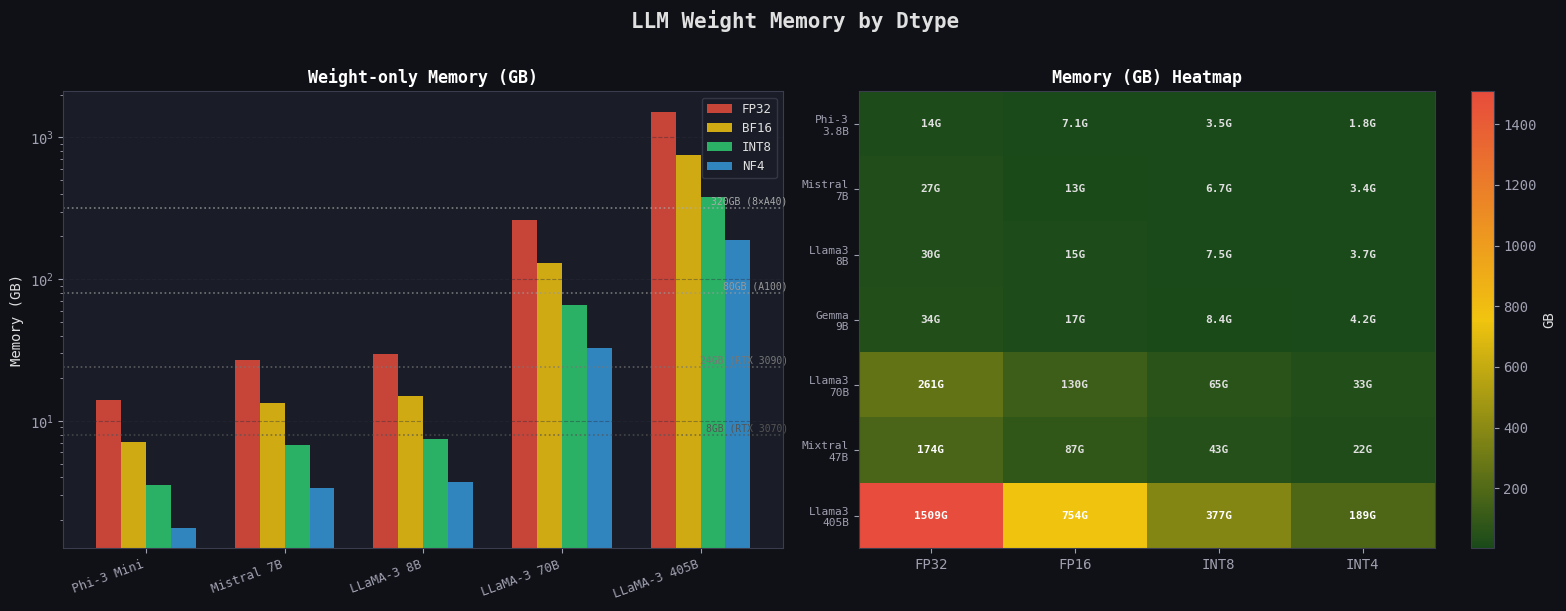


💡  Key insight: NF4 = FP32/8. A 70B model goes from 280GB → 35GB.


In [4]:
# ── Visualise: memory by model × dtype ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('LLM Weight Memory by Dtype', fontsize=15, fontweight='bold', y=1.01)

# Left: grouped bar chart
ax = axes[0]
display_models = ['Phi-3 Mini (3.8B)', 'Mistral 7B', 'LLaMA-3 8B', 'LLaMA-3 70B', 'LLaMA-3 405B']
dtype_items = [('FP32', C['fp32'], 32), ('BF16', C['bf16'], 16),
               ('INT8', C['int8'], 8),  ('NF4',  C['nf4'],  4)]

x = np.arange(len(display_models))
width = 0.18
for i, (label, color, bits) in enumerate(dtype_items):
    vals = [params_to_memory(models[m], bits)['GB'] for m in display_models]
    bars = ax.bar(x + i * width, vals, width, label=label, color=color, alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([m.split('(')[0].strip() for m in display_models], rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Memory (GB)')
ax.set_title('Weight-only Memory (GB)', fontweight='bold')
ax.set_yscale('log')
ax.yaxis.grid(True, alpha=0.4)
ax.legend(fontsize=9)

# Reference lines for common GPU VRAM
for vram, lbl, clr in [(8,'8GB (RTX 3070)','#555'), (24,'24GB (RTX 3090)','#777'),
                        (80,'80GB (A100)','#999'), (320,'320GB (8×A40)','#aaa')]:
    ax.axhline(vram, color=clr, linestyle=':', linewidth=1.2, alpha=0.7)
    ax.text(len(display_models)-0.1, vram*1.05, lbl, color=clr, fontsize=7, ha='right')

# Right: compression ratio heatmap
ax2 = axes[1]
all_models_short = ['Phi-3\n3.8B', 'Mistral\n7B', 'Llama3\n8B', 'Gemma\n9B',
                    'Llama3\n70B', 'Mixtral\n47B', 'Llama3\n405B']
all_model_keys = ['Phi-3 Mini (3.8B)', 'Mistral 7B', 'LLaMA-3 8B', 'Gemma 9B',
                  'LLaMA-3 70B', 'Mixtral 8×7B', 'LLaMA-3 405B']
dtype_labels = ['FP32', 'FP16', 'INT8', 'INT4']
bits_list = [32, 16, 8, 4]

heatmap_data = np.array([[params_to_memory(models[m], b)['GB']
                          for b in bits_list] for m in all_model_keys])

cmap = LinearSegmentedColormap.from_list('mem', ['#1a4a1a', '#f1c40f', '#e74c3c'])
im = ax2.imshow(heatmap_data, cmap=cmap, aspect='auto')
ax2.set_xticks(range(len(dtype_labels)))
ax2.set_xticklabels(dtype_labels, fontsize=10)
ax2.set_yticks(range(len(all_models_short)))
ax2.set_yticklabels(all_models_short, fontsize=8)
ax2.set_title('Memory (GB) Heatmap', fontweight='bold')

for i in range(len(all_model_keys)):
    for j in range(len(dtype_labels)):
        val = heatmap_data[i, j]
        txt = f'{val:.0f}G' if val >= 10 else f'{val:.1f}G'
        ax2.text(j, i, txt, ha='center', va='center', fontsize=8,
                 color='white' if val > 150 else '#e0e0e0', fontweight='bold')

plt.colorbar(im, ax=ax2, label='GB')
plt.tight_layout()
plt.savefig('memory_overview.png', dpi=140, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('\n💡  Key insight: NF4 = FP32/8. A 70B model goes from 280GB → 35GB.')

---
## Part 2 — Floating Point Formats: Bits Under the Hood

Every number stored in a model is encoded in binary. The **bit layout** determines:
- the **dynamic range** (how large/small a number can be)
- the **precision** (how finely spaced adjacent values are)

```
IEEE 754 Layout
─────────────────────────────────────────────────────────────────
FP32  [S|EEEEEEEE|MMMMMMMMMMMMMMMMMMMMMMM]   1+8+23 = 32 bits
FP16  [S|EEEEE|MMMMMMMMMM]                   1+5+10 = 16 bits  
BF16  [S|EEEEEEEE|MMMMMMM]                   1+8+7  = 16 bits
─────────────────────────────────────────────────────────────────
S = sign, E = exponent, M = mantissa (significand)
```

**BF16 vs FP16:** Same number of bits, radically different tradeoff.
- FP16: 10 mantissa bits → more precision, but tiny exponent → **overflows/underflows during training**
- BF16: 7 mantissa bits → same exponent range as FP32 → **numerically stable for training**

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2 · Floating point formats — bit anatomy
# ─────────────────────────────────────────────────────────────────────────────

formats = {
    'FP32':  {'total': 32, 'exp': 8,  'mant': 23, 'color': C['fp32']},
    'FP16':  {'total': 16, 'exp': 5,  'mant': 10, 'color': C['fp16']},
    'BF16':  {'total': 16, 'exp': 8,  'mant': 7,  'color': C['bf16']},
    'INT8':  {'total': 8,  'exp': 0,  'mant': 7,  'color': C['int8']},
    'INT4':  {'total': 4,  'exp': 0,  'mant': 3,  'color': C['int4']},
}

def max_abs_value(exp_bits, mant_bits):
    """Approx max representable value for a float format."""
    if exp_bits == 0:
        return 2**(mant_bits) - 1  # integer
    bias = 2**(exp_bits - 1) - 1
    max_exp = 2**exp_bits - 2 - bias   # exclude inf/nan exponent
    return (2 - 2**(-mant_bits)) * (2**max_exp)

def smallest_positive(exp_bits, mant_bits):
    """Smallest positive normal value."""
    if exp_bits == 0:
        return 1
    bias = 2**(exp_bits - 1) - 1
    return 2**(1 - bias)

print(f"{'Format':<8} {'Bits':>5} {'Exp':>5} {'Mant':>6} {'Max Value':>18} {'Min Positive':>18} {'Unique Values':>16}")
print('─' * 82)
for name, f in formats.items():
    mv  = max_abs_value(f['exp'], f['mant'])
    sp  = smallest_positive(f['exp'], f['mant'])
    uv  = 2 ** f['total']
    print(f"{name:<8} {f['total']:>5} {f['exp']:>5} {f['mant']:>6} {mv:>18.3e} {sp:>18.3e} {uv:>16,}")

Format    Bits   Exp   Mant          Max Value       Min Positive    Unique Values
──────────────────────────────────────────────────────────────────────────────────
FP32        32     8     23          3.403e+38          1.175e-38    4,294,967,296
FP16        16     5     10          6.550e+04          6.104e-05           65,536
BF16        16     8      7          3.390e+38          1.175e-38           65,536
INT8         8     0      7          1.270e+02          1.000e+00              256
INT4         4     0      3          7.000e+00          1.000e+00               16


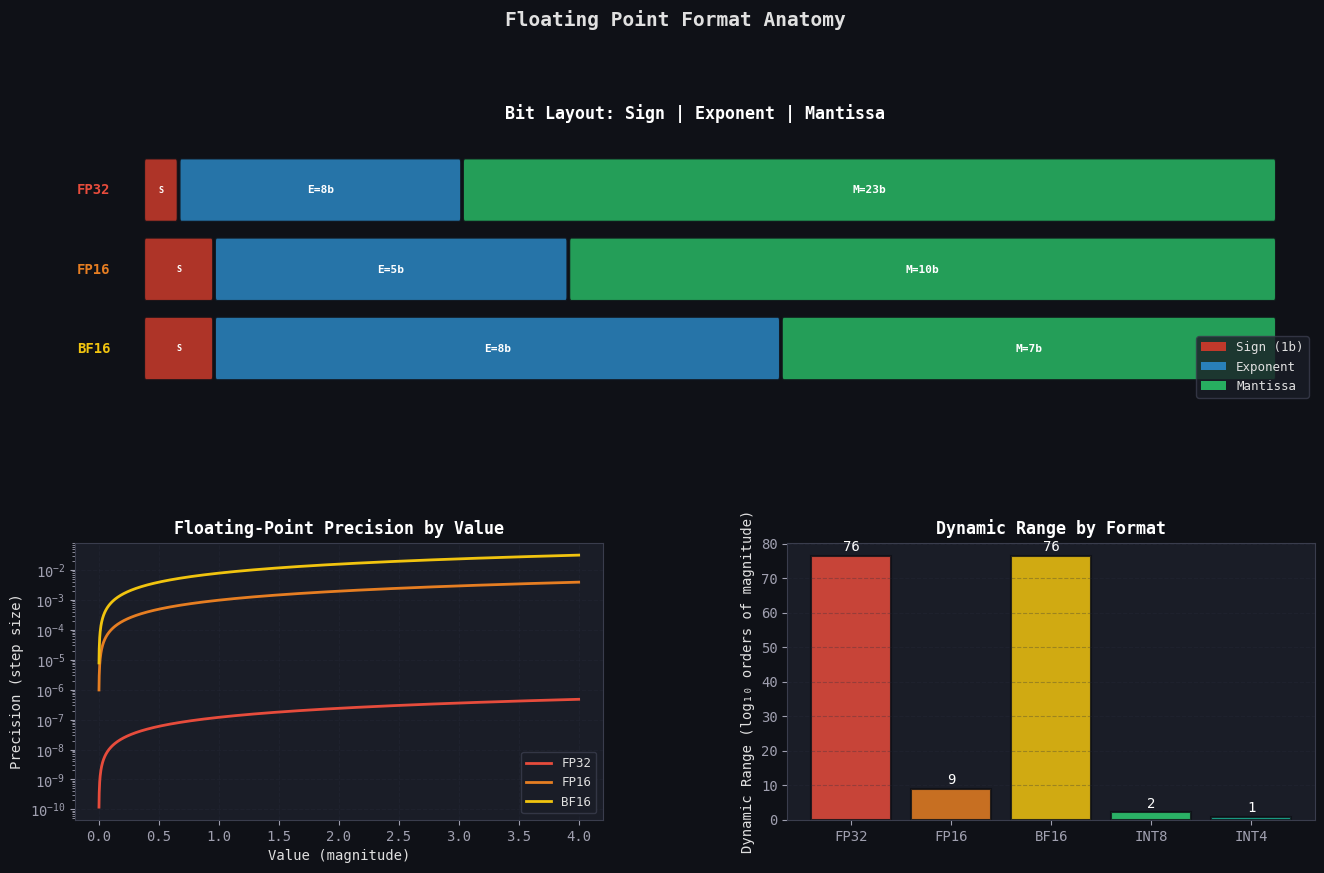


💡  BF16 shares FP32's exponent (same dynamic range), sacrificing 16 mantissa bits.
    This is why BF16 is stable for training — overflow is the killer, not imprecision.


In [7]:
# ── Visual: bit layout diagram + precision density ───────────────────────────
fig = plt.figure(figsize=(16, 9))
fig.patch.set_facecolor('#0f1117')
gs = gridspec.GridSpec(2, 2, hspace=0.5, wspace=0.35)

# ── 1. Bit layout strips ──
ax_bits = fig.add_subplot(gs[0, :])
ax_bits.set_facecolor('#0f1117')
ax_bits.set_title('Bit Layout: Sign | Exponent | Mantissa', fontweight='bold', fontsize=12)

fmt_order = ['FP32', 'FP16', 'BF16']
y_positions = [2.5, 1.5, 0.5]
box_h = 0.7

for yi, fname in zip(y_positions, fmt_order):
    f = formats[fname]
    total = f['total']
    # Normalise widths to 32-bit canvas
    scale = 32 / total
    x = 0
    segments = [('S', 1, '#c0392b'), ('E', f['exp'], '#2980b9'), ('M', f['mant'], '#27ae60')]
    for label, bits, color in segments:
        w = bits * scale
        rect = mpatches.FancyBboxPatch((x, yi - box_h/2), w - 0.15, box_h,
                                        boxstyle='round,pad=0.05', fc=color, ec='#0f1117', lw=1.5, alpha=0.9)
        ax_bits.add_patch(rect)
        lbl = f'{label}={bits}b' if bits > 2 else label
        ax_bits.text(x + w/2 - 0.08, yi, lbl, ha='center', va='center',
                     fontsize=8 if w > 3 else 6, color='white', fontweight='bold')
        x += w
    ax_bits.text(-1, yi, fname, ha='right', va='center', fontsize=10,
                 color=f['color'], fontweight='bold')

ax_bits.set_xlim(-2, 33)
ax_bits.set_ylim(-0.2, 3.3)
ax_bits.axis('off')

# Legend patches
legend_patches = [mpatches.Patch(fc='#c0392b', label='Sign (1b)'),
                  mpatches.Patch(fc='#2980b9', label='Exponent'),
                  mpatches.Patch(fc='#27ae60', label='Mantissa')]
ax_bits.legend(handles=legend_patches, loc='lower right', fontsize=9)

# ── 2. Precision density on number line ──
ax_prec = fig.add_subplot(gs[1, 0])
x_range = np.linspace(0.001, 4, 2000)

def relative_precision(x, mant_bits):
    return x * 2**(-mant_bits)

for fname, mbits, clr in [('FP32', 23, C['fp32']), ('FP16', 10, C['fp16']), ('BF16', 7, C['bf16'])]:
    ax_prec.plot(x_range, relative_precision(x_range, mbits), label=fname, color=clr, linewidth=2)

ax_prec.set_xlabel('Value (magnitude)')
ax_prec.set_ylabel('Precision (step size)')
ax_prec.set_title('Floating-Point Precision by Value', fontweight='bold')
ax_prec.legend(fontsize=9)
ax_prec.grid(True, alpha=0.3)
ax_prec.set_yscale('log')

# ── 3. Dynamic range comparison ──
ax_range = fig.add_subplot(gs[1, 1])
names = list(formats.keys())
log_ranges = []
for fname in names:
    f = formats[fname]
    mx = max_abs_value(f['exp'], f['mant'])
    mn = smallest_positive(f['exp'], f['mant'])
    log_ranges.append(math.log10(mx/mn) if mn > 0 and mx > 0 else 0)

colors_bar = [formats[n]['color'] for n in names]
bars = ax_range.bar(names, log_ranges, color=colors_bar, alpha=0.85, edgecolor='#0f1117', linewidth=1.5)
for bar, val in zip(bars, log_ranges):
    ax_range.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                  f'{val:.0f}', ha='center', va='bottom', fontsize=10, color='white')
ax_range.set_ylabel('Dynamic Range (log₁₀ orders of magnitude)')
ax_range.set_title('Dynamic Range by Format', fontweight='bold')
ax_range.grid(True, alpha=0.3, axis='y')

plt.suptitle('Floating Point Format Anatomy', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('fp_formats.png', dpi=140, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print('\n💡  BF16 shares FP32\'s exponent (same dynamic range), sacrificing 16 mantissa bits.')
print('    This is why BF16 is stable for training — overflow is the killer, not imprecision.')

---
## Part 3 — Quantization: The Core Idea

**Quantization** maps a continuous (high-precision) distribution of weights to a smaller discrete set of levels.

The fundamental operation:
$$x_q = \text{round}\left(\frac{x}{s}\right) + z \qquad x_{\text{deq}} = s \cdot (x_q - z)$$

Where:
- $s$ = **scale factor** (float, maps range of $x$ to range of integers)
- $z$ = **zero-point** (integer offset for asymmetric quantization)
- $x_q$ = quantized integer stored in memory

### Symmetric vs Asymmetric
- **Symmetric** ($z = 0$): weight range centered at 0. Simpler math.
- **Asymmetric**: uses the full integer range. Better for activations (often ReLU → all positive).

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3 · Quantization mechanics from scratch
# ─────────────────────────────────────────────────────────────────────────────

class LinearQuantizer:
    """Symmetric and asymmetric linear quantization — built from first principles."""

    def __init__(self, bits: int, symmetric: bool = True):
        self.bits = bits
        self.symmetric = symmetric
        if symmetric:
            # e.g. INT8 symmetric: -127..127 (reserve -128 for special use)
            self.q_min = -(2**(bits - 1) - 1)
            self.q_max =   2**(bits - 1) - 1
        else:
            # Unsigned: 0..255 for INT8
            self.q_min = 0
            self.q_max = 2**bits - 1

    def calibrate(self, x: np.ndarray):
        """Compute scale and zero-point from data range."""
        x_min, x_max = x.min(), x.max()
        if self.symmetric:
            abs_max = max(abs(x_min), abs(x_max))
            self.scale = abs_max / self.q_max
            self.zero_point = 0
        else:
            self.scale = (x_max - x_min) / (self.q_max - self.q_min)
            self.zero_point = self.q_min - round(x_min / self.scale)
            self.zero_point = int(np.clip(self.zero_point, self.q_min, self.q_max))
        return self

    def quantize(self, x: np.ndarray) -> np.ndarray:
        x_q = np.round(x / self.scale) + self.zero_point
        return np.clip(x_q, self.q_min, self.q_max).astype(np.int32)

    def dequantize(self, x_q: np.ndarray) -> np.ndarray:
        return self.scale * (x_q.astype(np.float32) - self.zero_point)

    def quantization_error(self, x: np.ndarray) -> dict:
        x_q  = self.quantize(x)
        x_r  = self.dequantize(x_q)
        err  = x - x_r
        return {
            'max_abs_error': np.abs(err).max(),
            'mean_abs_error': np.abs(err).mean(),
            'rmse': np.sqrt((err**2).mean()),
            'snr_db': 10 * np.log10(np.var(x) / np.var(err)) if np.var(err) > 0 else np.inf,
            'reconstructed': x_r,
            'quantized': x_q,
        }


# Simulate a realistic weight tensor (Gaussian, as actual LLM weights)
rng = np.random.default_rng(42)
weights = rng.normal(0, 0.02, size=10_000)  # typical transformer weight scale

print(f"Weight statistics → mean: {weights.mean():.5f}  std: {weights.std():.5f}")
print(f"                    min:  {weights.min():.5f}   max: {weights.max():.5f}")
print()

print(f"{'Config':<30} {'RMSE':>10} {'MaxErr':>10} {'SNR (dB)':>10}")
print('─' * 62)

configs = [
    ('INT8 Symmetric',   LinearQuantizer(8,  True)),
    ('INT8 Asymmetric',  LinearQuantizer(8,  False)),
    ('INT4 Symmetric',   LinearQuantizer(4,  True)),
    ('INT4 Asymmetric',  LinearQuantizer(4,  False)),
]

results = {}
for label, q in configs:
    q.calibrate(weights)
    r = q.quantization_error(weights)
    results[label] = r
    print(f"{label:<30} {r['rmse']:>10.6f} {r['max_abs_error']:>10.6f} {r['snr_db']:>10.2f}")

Weight statistics → mean: -0.00020  std: 0.02013
                    min:  -0.08778   max: 0.08052

Config                               RMSE     MaxErr   SNR (dB)
──────────────────────────────────────────────────────────────
INT8 Symmetric                   0.000198   0.000346      40.14
INT8 Asymmetric                  0.000189   0.000330      40.54
INT4 Symmetric                   0.003590   0.006270      14.97
INT4 Asymmetric                  0.003223   0.005609      15.91


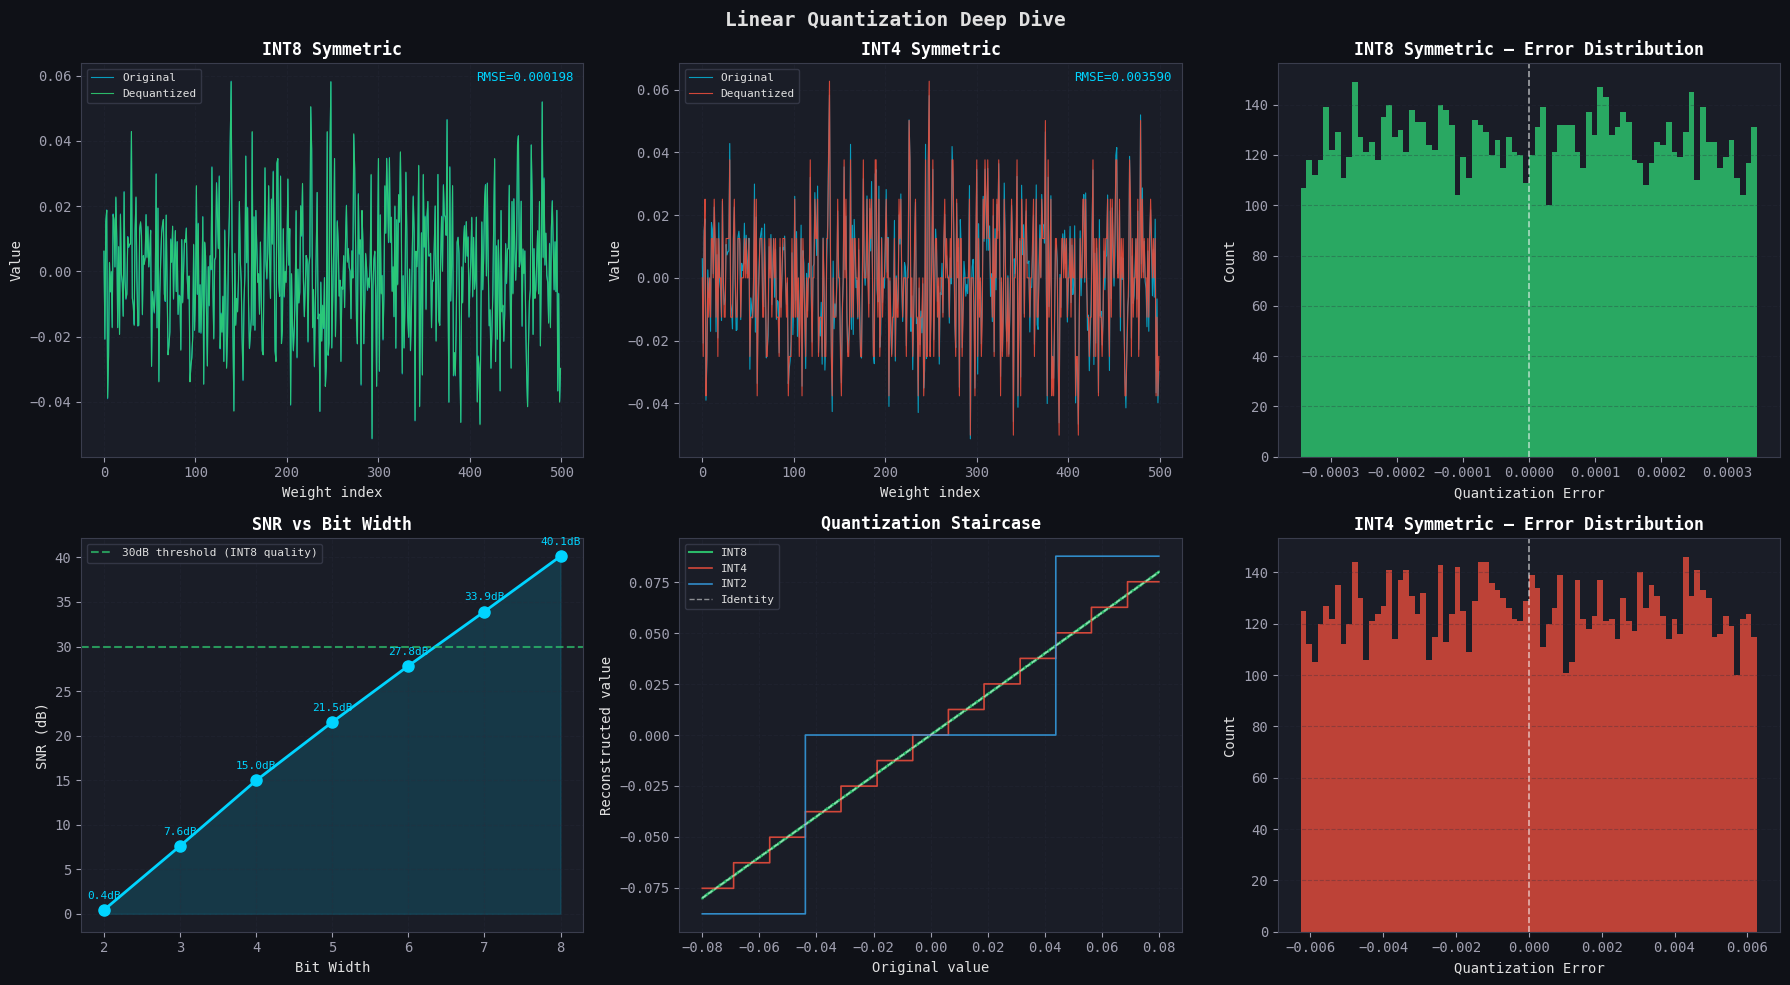


💡  Each additional bit doubles the number of quantization levels and roughly adds 6dB SNR.
    INT8 (48+ dB) is typically lossless in practice. INT4 (~24 dB) is where quality starts mattering.


In [9]:
# ── Visualise quantization error for INT8 vs INT4 ────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Linear Quantization Deep Dive', fontsize=14, fontweight='bold')

slice_w = weights[:500]   # plot a slice

# ─ Row 0: INT8 ─
for col_idx, (label, q) in enumerate([('INT8 Symmetric', LinearQuantizer(8, True)),
                                       ('INT4 Symmetric', LinearQuantizer(4, True))]):
    q.calibrate(weights)
    r = q.quantization_error(slice_w)
    ax = axes[0, col_index := col_idx]
    ax.plot(slice_w, color=C['accent'], linewidth=0.8, alpha=0.7, label='Original')
    ax.plot(r['reconstructed'], color=C['fp32'] if col_idx == 1 else C['int8'],
            linewidth=0.8, alpha=0.9, label='Dequantized')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Weight index')
    ax.set_ylabel('Value')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    rmse = results[label]['rmse']
    ax.text(0.98, 0.98, f'RMSE={rmse:.6f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color=C['accent'])

# ─ Middle col: error histogram ─
for row_idx, (label, q_bits) in enumerate([('INT8 Symmetric', 8), ('INT4 Symmetric', 4)]):
    q = LinearQuantizer(q_bits, True).calibrate(weights)
    r = q.quantization_error(weights)
    err = weights - r['reconstructed']
    ax = axes[row_idx, 2]
    ax.hist(err, bins=80, color=C['int8'] if q_bits == 8 else C['fp32'],
            alpha=0.8, edgecolor='none')
    ax.set_title(f'{label} — Error Distribution', fontweight='bold')
    ax.set_xlabel('Quantization Error')
    ax.set_ylabel('Count')
    ax.axvline(0, color='white', linestyle='--', linewidth=1.2, alpha=0.6)
    ax.grid(True, alpha=0.3, axis='y')

# ─ Bottom-left: SNR comparison across bit widths ─
ax_snr = axes[1, 0]
bit_widths = [2, 3, 4, 5, 6, 7, 8]
snrs = []
for b in bit_widths:
    q = LinearQuantizer(b, True).calibrate(weights)
    r = q.quantization_error(weights)
    snrs.append(r['snr_db'])

ax_snr.plot(bit_widths, snrs, 'o-', color=C['accent'], linewidth=2, markersize=8)
ax_snr.fill_between(bit_widths, snrs, alpha=0.15, color=C['accent'])
for bw, snr in zip(bit_widths, snrs):
    ax_snr.annotate(f'{snr:.1f}dB', (bw, snr), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=8, color=C['accent'])
ax_snr.axhline(30, color=C['int8'], linestyle='--', alpha=0.7, label='30dB threshold (INT8 quality)')
ax_snr.set_xlabel('Bit Width')
ax_snr.set_ylabel('SNR (dB)')
ax_snr.set_title('SNR vs Bit Width', fontweight='bold')
ax_snr.legend(fontsize=8)
ax_snr.grid(True, alpha=0.3)

# ─ Bottom-middle: quantization levels visualised ─
ax_lvl = axes[1, 1]
x_cont = np.linspace(-0.08, 0.08, 1000)
for bits, clr, lbl in [(8, C['int8'], 'INT8'), (4, C['fp32'], 'INT4'), (2, C['nf4'], 'INT2')]:
    q = LinearQuantizer(bits, True).calibrate(weights)
    x_q = q.quantize(x_cont)
    x_r = q.dequantize(x_q)
    ax_lvl.step(x_cont, x_r, where='mid', color=clr, linewidth=1.5 if bits==8 else 1.2, label=lbl, alpha=0.9)

ax_lvl.plot(x_cont, x_cont, color='white', linewidth=1, linestyle='--', alpha=0.5, label='Identity')
ax_lvl.set_xlabel('Original value')
ax_lvl.set_ylabel('Reconstructed value')
ax_lvl.set_title('Quantization Staircase', fontweight='bold')
ax_lvl.legend(fontsize=8)
ax_lvl.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('quantization_mechanics.png', dpi=140, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('\n💡  Each additional bit doubles the number of quantization levels and roughly adds 6dB SNR.')
print('    INT8 (48+ dB) is typically lossless in practice. INT4 (~24 dB) is where quality starts mattering.')

---
## Part 4 — Block-wise Quantization & Absmax

A single scale factor for an entire weight matrix is **too coarse** — outliers skew the range and waste precision. 

**Block-wise quantization:** split the weight tensor into blocks of size `B` (commonly 64 or 128), compute a separate scale per block.

The most common calibration method: **Absmax**
$$s_b = \frac{\max_{i \in b}|w_i|}{Q_{\max}}$$

This is what bitsandbytes (used by QLoRA/PEFT) does by default. Each block of 64 weights shares one FP32 scale constant.

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4 · Block-wise quantization and absmax calibration
# ─────────────────────────────────────────────────────────────────────────────

class BlockwiseQuantizer:
    """Block-wise absmax quantizer — the backbone of NF4/QLoRA."""

    def __init__(self, bits: int, block_size: int = 64):
        self.bits    = bits
        self.B       = block_size
        self.q_max   = 2**(bits - 1) - 1   # symmetric INT range

    def quantize(self, x: np.ndarray) -> dict:
        orig_shape = x.shape
        flat = x.flatten()
        n    = len(flat)
        # Pad to block multiple
        pad  = (self.B - n % self.B) % self.B
        flat = np.append(flat, np.zeros(pad))
        blocks  = flat.reshape(-1, self.B)
        scales  = np.abs(blocks).max(axis=1)  # absmax per block
        # Avoid div-by-zero
        safe_scales = np.where(scales == 0, 1.0, scales)
        # Quantize
        q_blocks = np.round(blocks / safe_scales[:, None] * self.q_max)
        q_blocks = np.clip(q_blocks, -self.q_max, self.q_max).astype(np.int8)
        return {'q_blocks': q_blocks, 'scales': scales,
                'orig_shape': orig_shape, 'n_orig': n, 'pad': pad}

    def dequantize(self, state: dict) -> np.ndarray:
        q_blocks = state['q_blocks'].astype(np.float32)
        safe_scales = np.where(state['scales'] == 0, 1.0, state['scales'])
        deq = q_blocks * safe_scales[:, None] / self.q_max
        flat = deq.flatten()[:state['n_orig']]
        return flat.reshape(state['orig_shape'])

    def memory_breakdown(self, n_params: int) -> dict:
        n_blocks      = math.ceil(n_params / self.B)
        weight_bits   = n_params * self.bits
        scale_bits    = n_blocks * 32            # FP32 scales
        total_bits    = weight_bits + scale_bits
        eff_bpw       = total_bits / n_params    # effective bits per weight
        return {
            'n_blocks':       n_blocks,
            'weight_bits':    weight_bits,
            'scale_bits':     scale_bits,
            'total_bits':     total_bits,
            'eff_bits_per_weight': eff_bpw,
            'weight_MB':      weight_bits / 8 / 1024**2,
            'scale_MB':       scale_bits  / 8 / 1024**2,
            'total_MB':       total_bits  / 8 / 1024**2,
        }


# Demonstrate with a simulated weight matrix (e.g., one transformer attention layer)
W = rng.normal(0, 0.02, size=(4096, 4096))  # typical 7B model attention weight
n_params = W.size

print('=== Block-wise INT4 Quantization Demo ===')
print(f'Tensor shape: {W.shape}  |  Parameters: {n_params:,}\n')

print(f'{'Block Size':<15} {'Eff. bpw':>10} {'Overhead %':>12} {'RMSE':>12} {'SNR (dB)':>10}')
print('─' * 62)

for block_size in [16, 32, 64, 128, 256, 512]:
    bq = BlockwiseQuantizer(bits=4, block_size=block_size)
    state = bq.quantize(W)
    W_r   = bq.dequantize(state)
    mem   = bq.memory_breakdown(n_params)
    err   = W - W_r
    rmse  = np.sqrt((err**2).mean())
    snr   = 10 * np.log10(np.var(W) / np.var(err))
    overhead_pct = (mem['scale_bits'] / mem['weight_bits']) * 100
    print(f'{block_size:<15} {mem["eff_bits_per_weight"]:>10.4f} {overhead_pct:>11.2f}% {rmse:>12.7f} {snr:>10.2f}')

print('\n💡  Smaller blocks → better quality (finer-grained scale), but scale overhead grows.')
print('    Block size 64 is the QLoRA default — good quality/overhead balance.')

=== Block-wise INT4 Quantization Demo ===
Tensor shape: (4096, 4096)  |  Parameters: 16,777,216

Block Size        Eff. bpw   Overhead %         RMSE   SNR (dB)
──────────────────────────────────────────────────────────────
16                  6.0000       50.00%    0.0017037      21.39
32                  5.0000       25.00%    0.0019402      20.26
64                  4.5000       12.50%    0.0021523      19.36
128                 4.2500        6.25%    0.0023468      18.61
256                 4.1250        3.12%    0.0025266      17.97
512                 4.0625        1.56%    0.0026954      17.41

💡  Smaller blocks → better quality (finer-grained scale), but scale overhead grows.
    Block size 64 is the QLoRA default — good quality/overhead balance.


---
## Part 5 — NF4: The Information-Theoretically Optimal 4-bit Format

Normal Float 4 (NF4) was introduced in the **QLoRA paper (Dettmers et al., 2023)** and is the key insight that made 4-bit finetuning practical.

**The core idea:**
> LLM weights, after block normalization, follow an approximately **normal (Gaussian) distribution** centered at 0. So why use uniformly-spaced quantization levels? Instead, place levels so that **each bin contains equal probability mass**.

This is the **quantile quantizer** applied to the standard normal — it minimizes expected quantization error for normally-distributed data.

$$q_i = \Phi^{-1}\!\left(\frac{i}{2^k - 1}\right) \quad \text{for } i = 0, 1, \ldots, 2^k - 1$$

where $\Phi^{-1}$ is the inverse CDF (probit function) of the standard normal, and $k = 4$.

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5 · NF4 — building the quantile codebook from scratch
# ─────────────────────────────────────────────────────────────────────────────

def normal_cdf(x):
    """Standard normal CDF via erf (no scipy needed)."""
    return 0.5 * (1 + math.erf(x / math.sqrt(2)))

def probit(p, tol=1e-8):
    """Inverse normal CDF via bisection."""
    lo, hi = -10.0, 10.0
    for _ in range(100):
        mid = (lo + hi) / 2
        if normal_cdf(mid) < p:
            lo = mid
        else:
            hi = mid
        if hi - lo < tol:
            break
    return (lo + hi) / 2

def build_nf4_codebook(bits=4):
    """
    Construct the NF4 codebook: 2^bits quantile-spaced levels
    over the standard normal distribution, normalized to [-1, 1].
    """
    n_levels = 2**bits  # 16 for NF4
    # Quantile positions: equally spaced probabilities
    quantiles = [(i + 0.5) / n_levels for i in range(n_levels)]
    levels = [probit(q) for q in quantiles]
    # Normalize to [-1, 1]
    abs_max = max(abs(levels[0]), abs(levels[-1]))
    levels = [l / abs_max for l in levels]
    return np.array(levels)

def build_uniform_codebook(bits=4):
    """Uniform INT4 levels in [-1, 1] for comparison."""
    n_levels = 2**bits
    return np.linspace(-1, 1, n_levels)


nf4_levels = build_nf4_codebook(bits=4)
int4_levels = build_uniform_codebook(bits=4)

print('NF4 Codebook (16 levels, normalized to [-1, 1]):')
print(f'  {[f"{v:.4f}" for v in nf4_levels]}')
print('\nINT4 Uniform Codebook (16 levels):')
print(f'  {[f"{v:.4f}" for v in int4_levels]}')

# Spacing analysis
nf4_gaps = np.diff(nf4_levels)
int4_gaps = np.diff(int4_levels)
print(f'\nNF4 gaps  →  min: {nf4_gaps.min():.4f}  max: {nf4_gaps.max():.4f}  (denser near 0)')
print(f'INT4 gaps →  min: {int4_gaps.min():.4f}  max: {int4_gaps.max():.4f}  (uniform)')

NF4 Codebook (16 levels, normalized to [-1, 1]):
  ['-1.0000', '-0.7076', '-0.5422', '-0.4168', '-0.3109', '-0.2159', '-0.1273', '-0.0421', '0.0421', '0.1273', '0.2159', '0.3109', '0.4168', '0.5422', '0.7076', '1.0000']

INT4 Uniform Codebook (16 levels):
  ['-1.0000', '-0.8667', '-0.7333', '-0.6000', '-0.4667', '-0.3333', '-0.2000', '-0.0667', '0.0667', '0.2000', '0.3333', '0.4667', '0.6000', '0.7333', '0.8667', '1.0000']

NF4 gaps  →  min: 0.0842  max: 0.2924  (denser near 0)
INT4 gaps →  min: 0.1333  max: 0.1333  (uniform)


In [12]:
class NF4Quantizer:
    """
    NF4 quantization:
    1. Normalize each block by absmax → values in [-1, 1]
    2. Find nearest codebook entry (chunked to stay memory-efficient)
    3. Store 4-bit index + FP32 absmax scale per block
    """

    def __init__(self, block_size=64, chunk_size=4096):
        self.B          = block_size
        self.cb         = build_nf4_codebook(bits=4)   # 16 levels
        self.n_bits     = 4
        self.chunk_size = chunk_size  # blocks per chunk (avoids OOM on large tensors)

    def _nearest_chunked(self, normed: np.ndarray) -> np.ndarray:
        """Memory-efficient chunked nearest-codebook-entry lookup."""
        n_blocks = normed.shape[0]
        idx = np.empty((n_blocks, self.B), dtype=np.uint8)
        for start in range(0, n_blocks, self.chunk_size):
            end   = min(start + self.chunk_size, n_blocks)
            chunk = normed[start:end]                           # (C, B)
            dists = np.abs(chunk[:, :, None] - self.cb[None, None, :])  # (C, B, 16)
            idx[start:end] = dists.argmin(axis=-1).astype(np.uint8)
        return idx

    def quantize(self, x: np.ndarray):
        flat   = x.flatten()
        n      = len(flat)
        pad    = (self.B - n % self.B) % self.B
        flat   = np.append(flat, np.zeros(pad))
        blocks = flat.reshape(-1, self.B)
        scales = np.abs(blocks).max(axis=1)
        safe_s = np.where(scales == 0, 1.0, scales)
        normed = blocks / safe_s[:, None]              # normalize to [-1,1]
        idx    = self._nearest_chunked(normed)
        return {'idx': idx, 'scales': scales, 'orig_shape': x.shape, 'n_orig': n, 'pad': pad}

    def dequantize(self, state):
        rec    = self.cb[state['idx'].astype(int)]     # lookup values
        deq    = rec * state['scales'][:, None]
        return deq.flatten()[:state['n_orig']].reshape(state['orig_shape'])


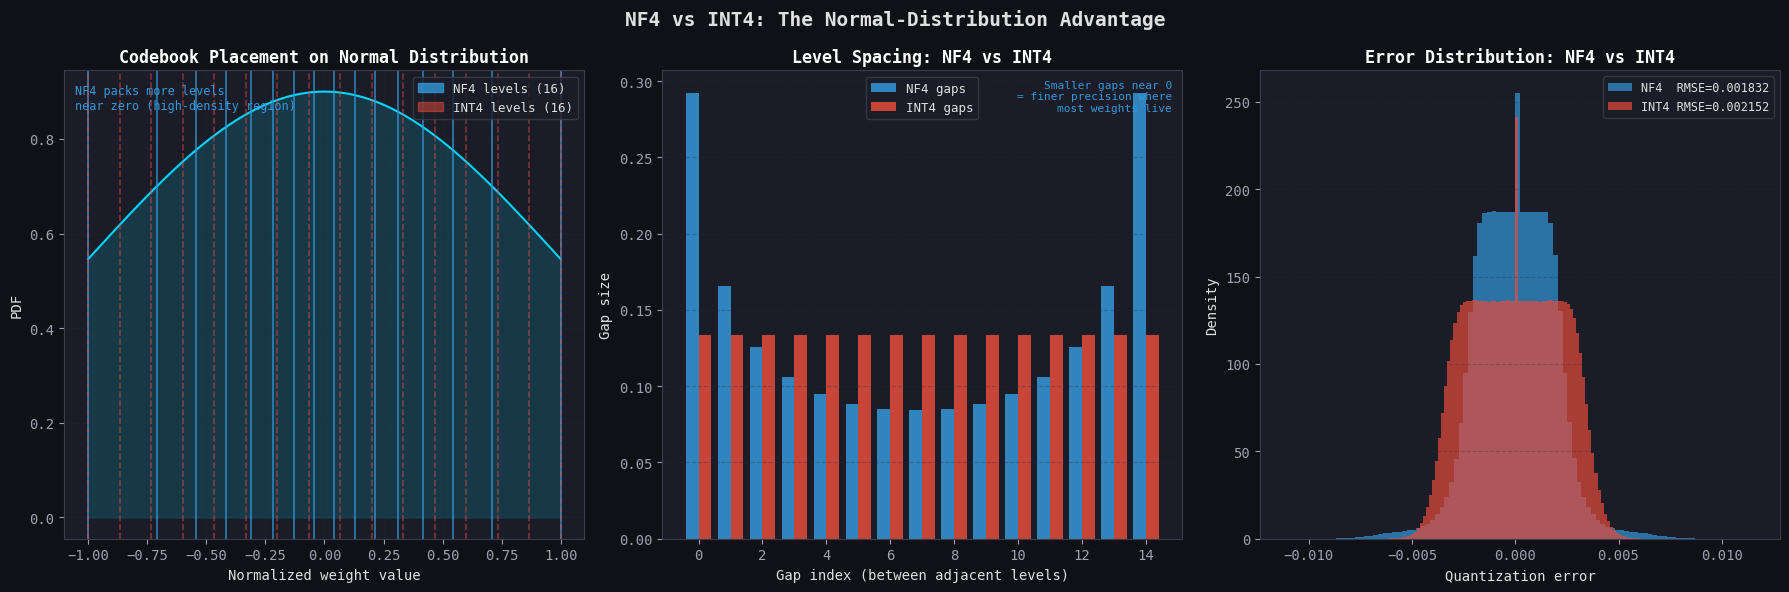


💡  NF4 is information-theoretically optimal for zero-mean Gaussian data.
    It exploits the fact that >90% of weight values cluster near zero.


In [13]:
# ── Visualise NF4 vs INT4 codebook placement ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('NF4 vs INT4: The Normal-Distribution Advantage', fontsize=14, fontweight='bold')

# ─ Left: codebook levels on normal PDF ─
ax = axes[0]
x_range = np.linspace(-1, 1, 500)
std = W.std()
mu  = W.mean()
# Plot normal PDF (normalised to [-1,1] for overlay)
norm_pdf = np.exp(-0.5 * (x_range)**2) / (np.sqrt(2 * np.pi))
norm_pdf = norm_pdf / norm_pdf.max() * 0.9
ax.fill_between(x_range, norm_pdf, alpha=0.15, color=C['accent'])
ax.plot(x_range, norm_pdf, color=C['accent'], linewidth=1.5, label='Normal PDF')

for lvl in nf4_levels:
    ax.axvline(lvl, color=C['nf4'], alpha=0.8, linewidth=1.2)
for lvl in int4_levels:
    ax.axvline(lvl, color=C['fp32'], alpha=0.5, linewidth=1.2, linestyle='--')

nf4_patch  = mpatches.Patch(color=C['nf4'],  label=f'NF4 levels ({len(nf4_levels)})', alpha=0.8)
int4_patch = mpatches.Patch(color=C['fp32'], label=f'INT4 levels ({len(int4_levels)})', alpha=0.5)
ax.legend(handles=[nf4_patch, int4_patch], fontsize=9)
ax.set_title('Codebook Placement on Normal Distribution', fontweight='bold')
ax.set_xlabel('Normalized weight value')
ax.set_ylabel('PDF')
ax.grid(True, alpha=0.3)
ax.text(0.02, 0.97, 'NF4 packs more levels\nnear zero (high-density region)',
        transform=ax.transAxes, va='top', fontsize=8.5, color=C['nf4'])

# ─ Middle: gap sizes ─
ax2 = axes[1]
positions = np.arange(15)
w_bar = 0.4
ax2.bar(positions - w_bar/2, nf4_gaps,  w_bar, color=C['nf4'],  alpha=0.85, label='NF4 gaps')
ax2.bar(positions + w_bar/2, int4_gaps, w_bar, color=C['fp32'], alpha=0.85, label='INT4 gaps')
ax2.set_xlabel('Gap index (between adjacent levels)')
ax2.set_ylabel('Gap size')
ax2.set_title('Level Spacing: NF4 vs INT4', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')
ax2.text(0.98, 0.98, 'Smaller gaps near 0\n= finer precision where\nmost weights live',
         transform=ax2.transAxes, ha='right', va='top', fontsize=8, color=C['nf4'])

# ─ Right: error histograms side by side ─
ax3 = axes[2]
sample = W.flatten()
nf4_state  = NF4Quantizer(64).quantize(sample.reshape(-1, 1))
int4_state = BlockwiseQuantizer(4, 64).quantize(sample)

err_n4 = (sample - NF4Quantizer(64).dequantize(
    NF4Quantizer(64).quantize(sample.reshape(-1,1))).flatten())
err_i4 = sample - BlockwiseQuantizer(4,64).dequantize(
    BlockwiseQuantizer(4,64).quantize(sample))

ax3.hist(err_n4, bins=100, alpha=0.7, color=C['nf4'],  label=f'NF4  RMSE={np.sqrt((err_n4**2).mean()):.6f}', density=True)
ax3.hist(err_i4, bins=100, alpha=0.7, color=C['fp32'], label=f'INT4 RMSE={np.sqrt((err_i4**2).mean()):.6f}', density=True)
ax3.set_xlabel('Quantization error')
ax3.set_ylabel('Density')
ax3.set_title('Error Distribution: NF4 vs INT4', fontweight='bold')
ax3.legend(fontsize=8.5)
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('nf4_analysis.png', dpi=140, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print('\n💡  NF4 is information-theoretically optimal for zero-mean Gaussian data.')
print('    It exploits the fact that >90% of weight values cluster near zero.')

---
## Part 6 — Double Quantization (QLoRA's Secret Weapon)

Block-wise quantization stores **one FP32 scale per block of 64 weights**. With a 7B model:

$$\frac{7 \times 10^9}{64} \times 4 \text{ bytes} \approx 437 \text{ MB}$$

That's substantial overhead. **Double Quantization** quantizes the scale constants themselves!

- **First quantization:** weights → NF4 (4-bit), scale constants in FP32
- **Second quantization:** group the FP32 scales (e.g., 256 scales per superblock) → quantize scales to **FP8** or **INT8**

The result: scales go from 32 bits → ~8 bits, **saving ~0.37 bits per weight** on a 7B model (~0.5 GB).

The second-level scales (for the scales-of-scales) remain in FP32 — but there are very few of them.

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6 · Double quantization — quantizing the quantization constants
# ─────────────────────────────────────────────────────────────────────────────

class DoubleQuantizer:
    """
    Two-level quantization:
    Level 1: NF4 weights with FP32 block scales  (block_size_1 = 64)
    Level 2: Quantize those scales to INT8        (block_size_2 = 256 scale-groups)
    """

    def __init__(self, block_size_1=64, block_size_2=256, q1_bits=4, q2_bits=8):
        self.B1      = block_size_1
        self.B2      = block_size_2
        self.q1_bits = q1_bits
        self.q2_bits = q2_bits
        self.cb_nf4  = build_nf4_codebook(bits=q1_bits)

    def quantize(self, x: np.ndarray):
        flat   = x.flatten()
        n      = len(flat)
        # ─── Level 1: NF4 weights ────────────────────────────────────────────
        pad1   = (self.B1 - n % self.B1) % self.B1
        flat1  = np.append(flat, np.zeros(pad1)).reshape(-1, self.B1)
        scales1 = np.abs(flat1).max(axis=1).astype(np.float32)
        s1_safe = np.where(scales1 == 0, 1.0, scales1)
        normed = flat1 / s1_safe[:, None]
        dists  = np.abs(normed[:, :, None] - self.cb_nf4[None, None, :])
        idx_nf4 = dists.argmin(axis=-1).astype(np.uint8)

        # ─── Level 2: quantize scales1 ────────────────────────────────────────
        n_s    = len(scales1)
        pad2   = (self.B2 - n_s % self.B2) % self.B2
        s1_pad = np.append(scales1, np.zeros(pad2)).reshape(-1, self.B2)
        # absmax-quantize each superblock of scales to INT8
        scales2  = np.abs(s1_pad).max(axis=1).astype(np.float32)  # superblock scales
        s2_safe  = np.where(scales2 == 0, 1.0, scales2)
        q_max2   = 2**(self.q2_bits - 1) - 1
        s1_q     = np.round(s1_pad / s2_safe[:, None] * q_max2)
        s1_q     = np.clip(s1_q, -q_max2, q_max2).astype(np.int8)

        return {
            'idx_nf4': idx_nf4, 's1_q': s1_q, 'scales2': scales2,
            'orig_shape': x.shape, 'n_orig': n, 'n_s_orig': n_s,
            'pad1': pad1, 'pad2': pad2
        }

    def dequantize(self, state):
        # Restore scales1
        q_max2   = 2**(self.q2_bits - 1) - 1
        s1_deq   = state['s1_q'].astype(np.float32) / q_max2 * state['scales2'][:, None]
        scales1  = s1_deq.flatten()[:state['n_s_orig']]
        # Restore weights
        values   = self.cb_nf4[state['idx_nf4'].astype(int)]
        recon    = values * scales1[:, None]
        return recon.flatten()[:state['n_orig']].reshape(state['orig_shape'])

    def bits_per_weight(self, n_params):
        n_blocks1    = math.ceil(n_params / self.B1)
        n_blocks2    = math.ceil(n_blocks1 / self.B2)
        weight_bits  = n_params   * self.q1_bits
        scale1_bits  = n_blocks1  * self.q2_bits   # INT8 quantized scales
        scale2_bits  = n_blocks2  * 32             # FP32 superblock scales (tiny)
        total_bits   = weight_bits + scale1_bits + scale2_bits
        return {
            'eff_bpw': total_bits / n_params,
            'weight_bits': weight_bits,
            'scale1_bits': scale1_bits,
            'scale2_bits': scale2_bits,
            'total_bits':  total_bits,
        }


# Compare single vs double quantization on 7B scale
n_7b = 7_000_000_000

single_q = BlockwiseQuantizer(bits=4, block_size=64)
double_q = DoubleQuantizer(block_size_1=64, block_size_2=256)

# Memory breakdown
single_mem = single_q.memory_breakdown(n_7b)
double_mem = double_q.bits_per_weight(n_7b)

print('=== 7B Model — Single vs Double Quantization ===' )
print()
print(f"{'Component':<30} {'Single Q (NF4)':>18} {'Double Q (NF4+INT8)':>20}")
print('─' * 72)
print(f"{'Weights (NF4, 4-bit)':<30} {single_mem['weight_bits']/8/1e9:>15.2f} GB {double_mem['weight_bits']/8/1e9:>17.2f} GB")
print(f"{'Block scales (FP32)':<30} {single_mem['scale_bits']/8/1e9:>15.2f} GB {'—':>17}")
print(f"{'Block scales (INT8)':<30} {'—':>15} {double_mem['scale1_bits']/8/1e9:>17.4f} GB")
print(f"{'Superblock scales (FP32)':<30} {'—':>15} {double_mem['scale2_bits']/8/1e9:>17.6f} GB")
print('─' * 72)
print(f"{'TOTAL':<30} {single_mem['total_bits']/8/1e9:>15.2f} GB {double_mem['total_bits']/8/1e9:>17.2f} GB")
print(f"{'Eff. bits/weight':<30} {single_mem['eff_bits_per_weight']:>15.4f}    {double_mem['eff_bpw']:>17.4f}")
savings = (single_mem['total_bits'] - double_mem['total_bits']) / 8 / 1e6
print(f'\nDouble quantization saves: {savings:.0f} MB on a 7B model')

=== 7B Model — Single vs Double Quantization ===

Component                          Single Q (NF4)  Double Q (NF4+INT8)
────────────────────────────────────────────────────────────────────────
Weights (NF4, 4-bit)                      3.50 GB              3.50 GB
Block scales (FP32)                       0.44 GB                 —
Block scales (INT8)                          —            0.1094 GB
Superblock scales (FP32)                     —          0.001709 GB
────────────────────────────────────────────────────────────────────────
TOTAL                                     3.94 GB              3.61 GB
Eff. bits/weight                        4.5000               4.1270

Double quantization saves: 326 MB on a 7B model


In [15]:
# ── Verify reconstruction quality of double quantization ─────────────────────
dq = DoubleQuantizer(block_size_1=64, block_size_2=256)
state_dq = dq.quantize(W)
W_dq     = dq.dequantize(state_dq)

err_dq   = W - W_dq
rmse_dq  = np.sqrt((err_dq**2).mean())
snr_dq   = 10 * np.log10(np.var(W) / np.var(err_dq))

nf4 = NF4Quantizer(block_size=64)
W_nf4s = nf4.dequantize(nf4.quantize(W))
err_nf4s = W - W_nf4s
rmse_nf4s = np.sqrt((err_nf4s**2).mean())
snr_nf4s  = 10 * np.log10(np.var(W) / np.var(err_nf4s))

print('Reconstruction quality comparison:')
print(f'  NF4 only       →  RMSE: {rmse_nf4s:.8f}  SNR: {snr_nf4s:.3f} dB')
print(f'  NF4 + DQ       →  RMSE: {rmse_dq:.8f}  SNR: {snr_dq:.3f} dB')
print(f'  SNR degradation from DQ: {snr_nf4s - snr_dq:.4f} dB  ← negligible in practice')

Reconstruction quality comparison:
  NF4 only       →  RMSE: 0.00183181  SNR: 20.761 dB
  NF4 + DQ       →  RMSE: 0.00183330  SNR: 20.754 dB
  SNR degradation from DQ: 0.0070 dB  ← negligible in practice


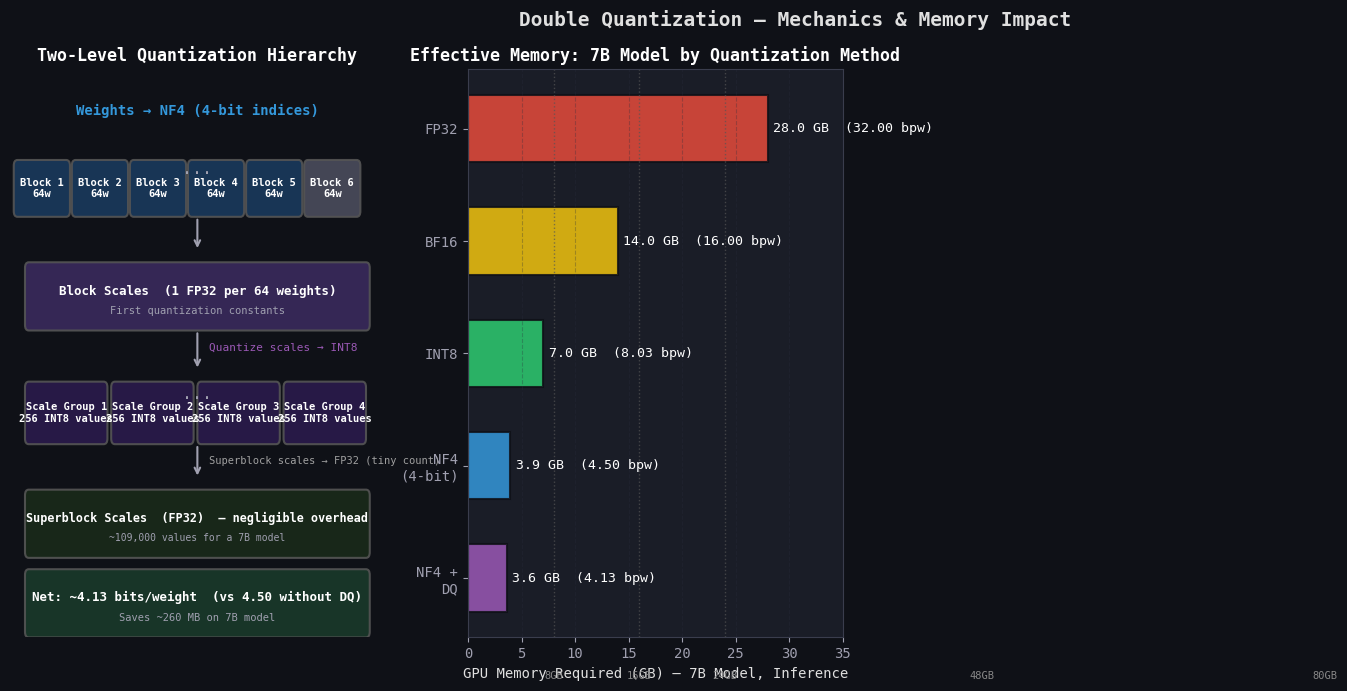


💡  QLoRA uses NF4 + Double Quantization for the frozen base model,
    and trains tiny LoRA adapters in BF16. Total footprint: ~6GB for a 7B fine-tune.


In [16]:
# ── Double quantization diagram + memory waterfall ───────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Double Quantization — Mechanics & Memory Impact', fontsize=14, fontweight='bold')

# ─ Left: hierarchical structure diagram ─
ax1.set_facecolor('#0f1117')
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis('off')
ax1.set_title('Two-Level Quantization Hierarchy', fontweight='bold')

def draw_box(ax, x, y, w, h, label, sublabel='', color='#2a2d3d', text_color='white', fontsize=10):
    rect = mpatches.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.1',
                                    fc=color, ec='#555', lw=1.5, alpha=0.9)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2 + (0.1 if sublabel else 0), label,
            ha='center', va='center', color=text_color, fontsize=fontsize, fontweight='bold')
    if sublabel:
        ax.text(x + w/2, y + h/2 - 0.25, sublabel,
                ha='center', va='center', color='#a0a0b0', fontsize=fontsize-1.5)

# Weight blocks
for i in range(6):
    clr = C['nf4'] if i < 5 else C['dim']
    draw_box(ax1, 0.2 + i*1.55, 7.5, 1.3, 0.8, f'Block {i+1}\n64w', color='#1a3a5c' if i<5 else C['dim'], fontsize=7.5)
ax1.text(5, 8.15, '...', ha='center', color='#a0a0b0', fontsize=12)
ax1.text(5, 9.2, 'Weights → NF4 (4-bit indices)', ha='center', color=C['nf4'], fontsize=10, fontweight='bold')

# Arrow down
ax1.annotate('', xy=(5, 6.8), xytext=(5, 7.4),
             arrowprops=dict(arrowstyle='->', color='#a0a0b0', lw=1.5))

# Scale blocks
draw_box(ax1, 0.5, 5.5, 9, 1.0, 'Block Scales  (1 FP32 per 64 weights)',
         sublabel='First quantization constants', color='#3a2a5c', fontsize=9)

ax1.annotate('', xy=(5, 4.7), xytext=(5, 5.4),
             arrowprops=dict(arrowstyle='->', color='#a0a0b0', lw=1.5))
ax1.text(5.3, 5.05, 'Quantize scales → INT8', color=C['dq'], fontsize=8)

# Quantized scales
for i in range(4):
    draw_box(ax1, 0.5 + i*2.3, 3.5, 2.0, 0.9, f'Scale Group {i+1}\n256 INT8 values',
             color='#2a1a4c', fontsize=7.5)
ax1.text(5, 4.2, '...', ha='center', color='#a0a0b0', fontsize=12)

ax1.annotate('', xy=(5, 2.8), xytext=(5, 3.4),
             arrowprops=dict(arrowstyle='->', color='#a0a0b0', lw=1.5))
ax1.text(5.3, 3.05, 'Superblock scales → FP32 (tiny count)', color='#a0a0a0', fontsize=7.5)

draw_box(ax1, 0.5, 1.5, 9, 1.0, 'Superblock Scales  (FP32)  — negligible overhead',
         sublabel='~109,000 values for a 7B model', color='#1a2a1a', fontsize=8.5)

# Summary box
draw_box(ax1, 0.5, 0.1, 9, 1.0,
         f'Net: ~4.13 bits/weight  (vs 4.50 without DQ)',
         sublabel='Saves ~260 MB on 7B model', color='#1a3a2a', fontsize=9)

# ─ Right: memory waterfall comparison ─
methods = ['FP32', 'BF16', 'INT8', 'NF4\n(4-bit)', 'NF4 +\nDQ']
bits_eff = [32, 16, 8.03, 4.5, 4.13]  # effective bits/weight for 7B
mem_gb_7b = [b * n_7b / 8 / 1e9 for b in bits_eff]
colors_w  = [C['fp32'], C['bf16'], C['int8'], C['nf4'], C['dq']]

bars = ax2.barh(methods, mem_gb_7b, color=colors_w, alpha=0.85, edgecolor='#0f1117', linewidth=1.5, height=0.6)
for bar, val, bpw in zip(bars, mem_gb_7b, bits_eff):
    ax2.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f} GB  ({bpw:.2f} bpw)', va='center', fontsize=9.5, color='white')

# GPU lines
for vram, lbl in [(8,'8GB'), (16,'16GB'), (24,'24GB'), (48,'48GB'), (80,'80GB')]:
    ax2.axvline(vram, color='#555', linestyle=':', linewidth=1, alpha=0.7)
    ax2.text(vram, len(methods)-0.1, lbl, color='#888', fontsize=7.5, ha='center')

ax2.set_xlabel('GPU Memory Required (GB) — 7B Model, Inference')
ax2.set_title('Effective Memory: 7B Model by Quantization Method', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')
ax2.set_xlim(0, max(mem_gb_7b) * 1.25)
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('double_quantization.png', dpi=140, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print('\n💡  QLoRA uses NF4 + Double Quantization for the frozen base model,')
print('    and trains tiny LoRA adapters in BF16. Total footprint: ~6GB for a 7B fine-tune.')

---
## Part 7 — Full Memory Budget: Beyond Just Weights

Model weights are only **one slice** of GPU memory during training and inference.

| Component | Training | Inference |
|-----------|----------|-----------|
| Model weights | ✅ | ✅ |
| Optimizer states (Adam) | 2× weights (m + v in FP32) | ❌ |
| Gradients | 1× weights | ❌ |
| Activations | depends on sequence/batch | minimal |
| **KV Cache** | small | **can dominate** |

**The KV Cache** is generated during inference as the model processes each token:
$$\text{KV cache} = 2 \times n_{\text{layers}} \times n_{\text{heads}} \times d_{\text{head}} \times \text{seq\_len} \times \text{bytes\_per\_element}$$

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7 · Full GPU memory budget — weights + optimizer + KV cache
# ─────────────────────────────────────────────────────────────────────────────

# Actual architecture configs of popular models
MODEL_CONFIGS = {
    'Phi-3 Mini 3.8B': {
        'params': 3.8e9, 'layers': 32, 'n_heads': 32,  'n_kv_heads': 32,
        'd_model': 3072,  'd_head': 96,  'vocab': 32064,
    },
    'Mistral 7B': {
        'params': 7.24e9, 'layers': 32, 'n_heads': 32, 'n_kv_heads': 8,
        'd_model': 4096,  'd_head': 128, 'vocab': 32000,
    },
    'LLaMA-3 8B': {
        'params': 8.03e9, 'layers': 32, 'n_heads': 32, 'n_kv_heads': 8,
        'd_model': 4096,  'd_head': 128, 'vocab': 128256,
    },
    'LLaMA-3 70B': {
        'params': 70.6e9, 'layers': 80, 'n_heads': 64, 'n_kv_heads': 8,
        'd_model': 8192,  'd_head': 128, 'vocab': 128256,
    },
    'Mixtral 8×7B': {
        'params': 46.7e9, 'layers': 32, 'n_heads': 32, 'n_kv_heads': 8,
        'd_model': 4096,  'd_head': 128, 'vocab': 32000,
    },
}


def kv_cache_bytes(cfg, seq_len, batch_size=1, dtype_bytes=2):
    """
    KV cache memory:
    2 (K+V) × layers × kv_heads × d_head × seq_len × batch × bytes
    """
    return (2 * cfg['layers'] * cfg['n_kv_heads'] * cfg['d_head']
            * seq_len * batch_size * dtype_bytes)


def full_memory_budget(model_name, weight_dtype_bits=16, seq_len=2048,
                        batch_size=1, mode='inference', optimizer='adam'):
    cfg = MODEL_CONFIGS[model_name]
    P   = cfg['params']

    # Weights
    weight_bytes = P * weight_dtype_bits / 8

    # KV cache (BF16 by default)
    kv_bytes = kv_cache_bytes(cfg, seq_len, batch_size, dtype_bytes=2)

    if mode == 'training':
        # Adam: 2 FP32 states per param
        opt_bytes  = P * 4 * 2 if optimizer == 'adam' else P * 4
        grad_bytes = P * (weight_dtype_bits / 8)   # grads match weight dtype
        # Rough activation estimate (depends heavily on batch/seq)
        act_bytes  = batch_size * seq_len * cfg['d_model'] * cfg['layers'] * 2 * 2
        total = weight_bytes + opt_bytes + grad_bytes + act_bytes + kv_bytes
        return {
            'weights_GB':     weight_bytes / 1e9,
            'optimizer_GB':   opt_bytes    / 1e9,
            'gradients_GB':   grad_bytes   / 1e9,
            'activations_GB': act_bytes    / 1e9,
            'kv_cache_GB':    kv_bytes     / 1e9,
            'total_GB':       total        / 1e9,
        }
    else:
        total = weight_bytes + kv_bytes
        return {
            'weights_GB':  weight_bytes / 1e9,
            'kv_cache_GB': kv_bytes     / 1e9,
            'total_GB':    total        / 1e9,
        }


# Print inference budget across dtypes
print('=== Inference Memory Budget (seq_len=2048, batch=1) ===')
print()
for model_name in ['Mistral 7B', 'LLaMA-3 8B', 'LLaMA-3 70B']:
    print(f'  {model_name}')
    print(f"  {'Dtype':<10} {'Weights':>10} {'KV Cache':>10} {'Total':>10}")
    print(f"  {'─'*42}")
    for label, bits in [('BF16', 16), ('INT8', 8), ('NF4(~4.5)', 5)]:
        bud = full_memory_budget(model_name, weight_dtype_bits=bits, seq_len=2048)
        print(f"  {label:<10} {bud['weights_GB']:>9.2f}G {bud['kv_cache_GB']:>9.2f}G {bud['total_GB']:>9.2f}G")
    print()

# Training budget for 7B
print('=== Training Memory Budget — LLaMA-3 8B ===')
print()
bud = full_memory_budget('LLaMA-3 8B', weight_dtype_bits=16, seq_len=2048, batch_size=4, mode='training')
total = bud['total_GB']
for k, v in bud.items():
    pct = v / total * 100
    bar = '█' * int(pct / 3)
    print(f"  {k:<20} {v:>7.2f} GB  ({pct:>5.1f}%)  {bar}")

=== Inference Memory Budget (seq_len=2048, batch=1) ===

  Mistral 7B
  Dtype         Weights   KV Cache      Total
  ──────────────────────────────────────────
  BF16           14.48G      0.27G     14.75G
  INT8            7.24G      0.27G      7.51G
  NF4(~4.5)       4.53G      0.27G      4.79G

  LLaMA-3 8B
  Dtype         Weights   KV Cache      Total
  ──────────────────────────────────────────
  BF16           16.06G      0.27G     16.33G
  INT8            8.03G      0.27G      8.30G
  NF4(~4.5)       5.02G      0.27G      5.29G

  LLaMA-3 70B
  Dtype         Weights   KV Cache      Total
  ──────────────────────────────────────────
  BF16          141.20G      0.67G    141.87G
  INT8           70.60G      0.67G     71.27G
  NF4(~4.5)      44.12G      0.67G     44.80G

=== Training Memory Budget — LLaMA-3 8B ===

  weights_GB             16.06 GB  ( 15.8%)  █████
  optimizer_GB           64.24 GB  ( 63.1%)  █████████████████████
  gradients_GB           16.06 GB  ( 15.8%)  █████

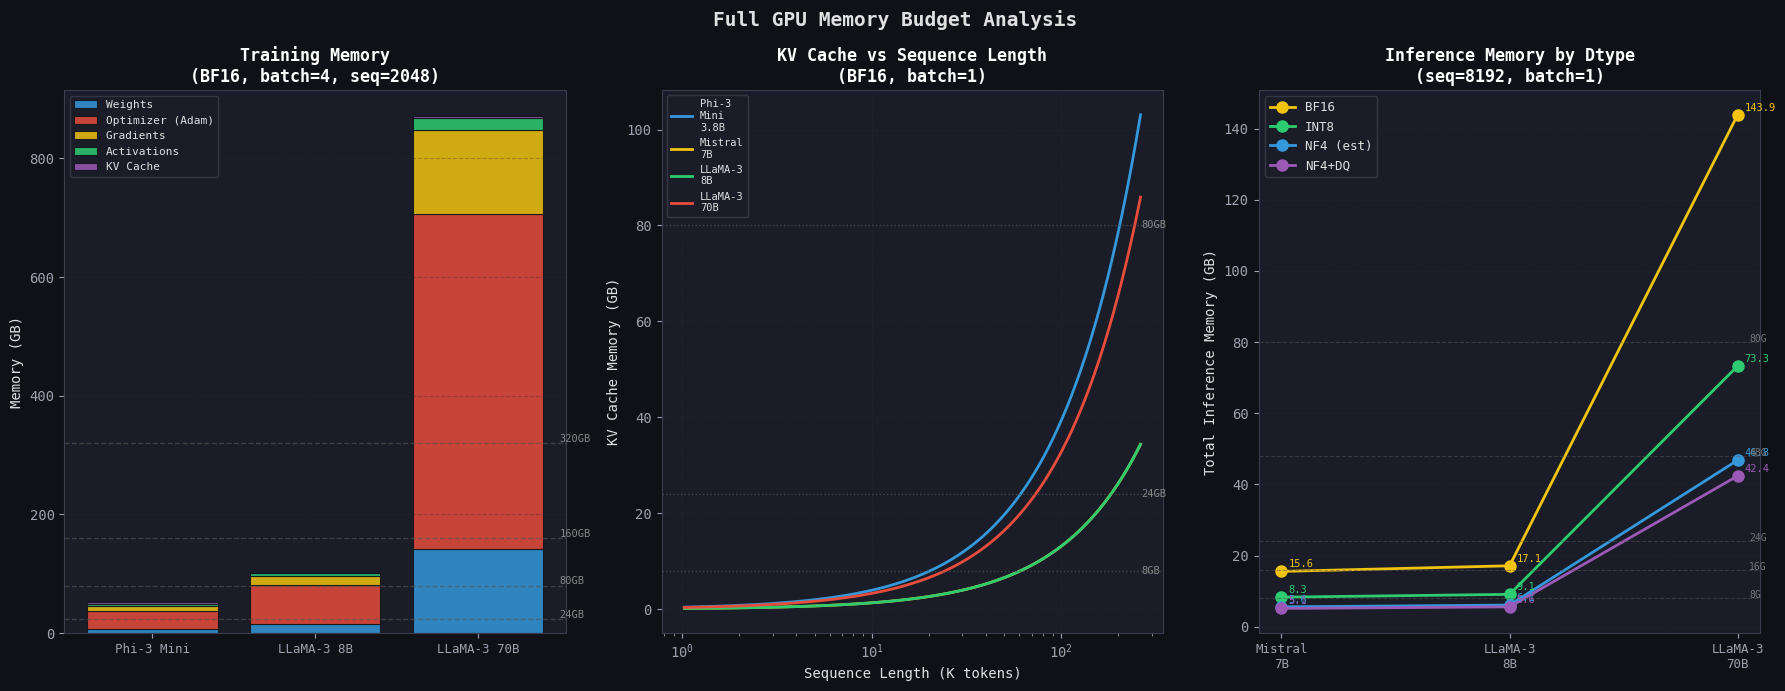


💡  For long-context inference (>32K tokens), KV cache can rival or exceed model weight memory.
    This is why KV cache quantization (e.g., INT8 KV) is a hot research area.


In [18]:
# ── KV cache growth with sequence length ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Full GPU Memory Budget Analysis', fontsize=14, fontweight='bold')

# ─ Left: training budget stacked bar ─
ax = axes[0]
train_models = ['Phi-3 Mini 3.8B', 'LLaMA-3 8B', 'LLaMA-3 70B']
components_clr = {
    'weights_GB':     (C['nf4'],   'Weights'),
    'optimizer_GB':   (C['fp32'],  'Optimizer (Adam)'),
    'gradients_GB':   (C['bf16'],  'Gradients'),
    'activations_GB': (C['int8'],  'Activations'),
    'kv_cache_GB':    (C['dq'],    'KV Cache'),
}

x   = np.arange(len(train_models))
bottom = np.zeros(len(train_models))
for key, (clr, lbl) in components_clr.items():
    vals = [full_memory_budget(m, 16, 2048, 4, 'training')[key] for m in train_models]
    ax.bar(x, vals, bottom=bottom, label=lbl, color=clr, alpha=0.85, edgecolor='#0f1117', linewidth=0.8)
    bottom += np.array(vals)

ax.set_xticks(x)
ax.set_xticklabels([m.split(' ')[0]+' '+m.split(' ')[1] for m in train_models], fontsize=9)
ax.set_ylabel('Memory (GB)')
ax.set_title('Training Memory\n(BF16, batch=4, seq=2048)', fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
for vram, lbl in [(24,'24GB'), (80,'80GB'), (160,'160GB'), (320,'320GB')]:
    ax.axhline(vram, color='#555', linestyle='--', linewidth=1, alpha=0.6)
    ax.text(len(x)-0.5, vram+2, lbl, color='#888', fontsize=7.5)
ax.grid(True, alpha=0.3, axis='y')

# ─ Middle: KV cache vs seq length ─
ax2 = axes[1]
seq_lens = np.logspace(10, 18, 100, base=2).astype(int)  # 1K to 256K
kv_models = ['Phi-3 Mini 3.8B', 'Mistral 7B', 'LLaMA-3 8B', 'LLaMA-3 70B']
kv_colors = [C['nf4'], C['bf16'], C['int8'], C['fp32']]

for mname, clr in zip(kv_models, kv_colors):
    cfg = MODEL_CONFIGS[mname]
    kv_gbs = [kv_cache_bytes(cfg, s, batch_size=1, dtype_bytes=2) / 1e9 for s in seq_lens]
    ax2.plot(seq_lens / 1000, kv_gbs, label=mname.replace(' ', '\n'), color=clr, linewidth=2)

for vram in [8, 24, 80]:
    ax2.axhline(vram, color='#555', linestyle=':', linewidth=1, alpha=0.7)
    ax2.text(seq_lens[-1]/1000 * 1.01, vram, f'{vram}GB', color='#888', fontsize=7.5, va='center')

ax2.set_xscale('log')
ax2.set_xlabel('Sequence Length (K tokens)')
ax2.set_ylabel('KV Cache Memory (GB)')
ax2.set_title('KV Cache vs Sequence Length\n(BF16, batch=1)', fontweight='bold')
ax2.legend(fontsize=7.5, loc='upper left')
ax2.grid(True, alpha=0.3)

# ─ Right: inference dtype comparison (donut-style) ─
ax3 = axes[2]
dtype_configs = [
    ('BF16',       16,  C['bf16']),
    ('INT8',        8,  C['int8']),
    ('NF4 (est)',   5,  C['nf4']),
    ('NF4+DQ',      4.5, C['dq']),
]

inf_models = ['Mistral 7B', 'LLaMA-3 8B', 'LLaMA-3 70B']
x3 = np.arange(len(inf_models))

for i, (lbl, bits, clr) in enumerate(dtype_configs):
    totals = [full_memory_budget(m, bits, 8192)['total_GB'] for m in inf_models]
    ax3.plot(x3, totals, 'o-', color=clr, linewidth=2, markersize=8, label=lbl)
    for xi, tv in zip(x3, totals):
        ax3.annotate(f'{tv:.1f}', (xi, tv), textcoords='offset points',
                     xytext=(5, 3), fontsize=7.5, color=clr)

ax3.set_xticks(x3)
ax3.set_xticklabels(['Mistral\n7B', 'LLaMA-3\n8B', 'LLaMA-3\n70B'], fontsize=9)
ax3.set_ylabel('Total Inference Memory (GB)')
ax3.set_title('Inference Memory by Dtype\n(seq=8192, batch=1)', fontweight='bold')
for vram in [8, 16, 24, 48, 80]:
    ax3.axhline(vram, color='#555', linestyle='--', linewidth=0.8, alpha=0.5)
    ax3.text(x3[-1]+0.05, vram, f'{vram}G', color='#777', fontsize=7)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('full_budget.png', dpi=140, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print('\n💡  For long-context inference (>32K tokens), KV cache can rival or exceed model weight memory.')
print('    This is why KV cache quantization (e.g., INT8 KV) is a hot research area.')

---
## Part 8 — Quantization Methods Landscape: GPTQ, GGUF, AWQ

| Method | Approach | Calibration | Speed | Quality | Where Used |
|--------|----------|-------------|-------|---------|------------|
| **RTN** | Round-to-nearest | None | Fastest | Worst | Baseline |
| **GPTQ** | Layer-wise OBQ (Hessian-guided) | ✅ ~128 samples | Slow offline, fast inference | High | GPU inference |
| **AWQ** | Salient weight protection | ✅ small set | Medium | Very High | GPU (vLLM) |
| **GGUF** | k-quants (grouped, mixed precision) | Configurable | Fast | Adjustable | CPU/Metal (llama.cpp) |
| **QLoRA** | NF4 + DQ for base, BF16 LoRA | LoRA training | N/A (training) | Preserves fine-tune | Fine-tuning on consumer GPU |

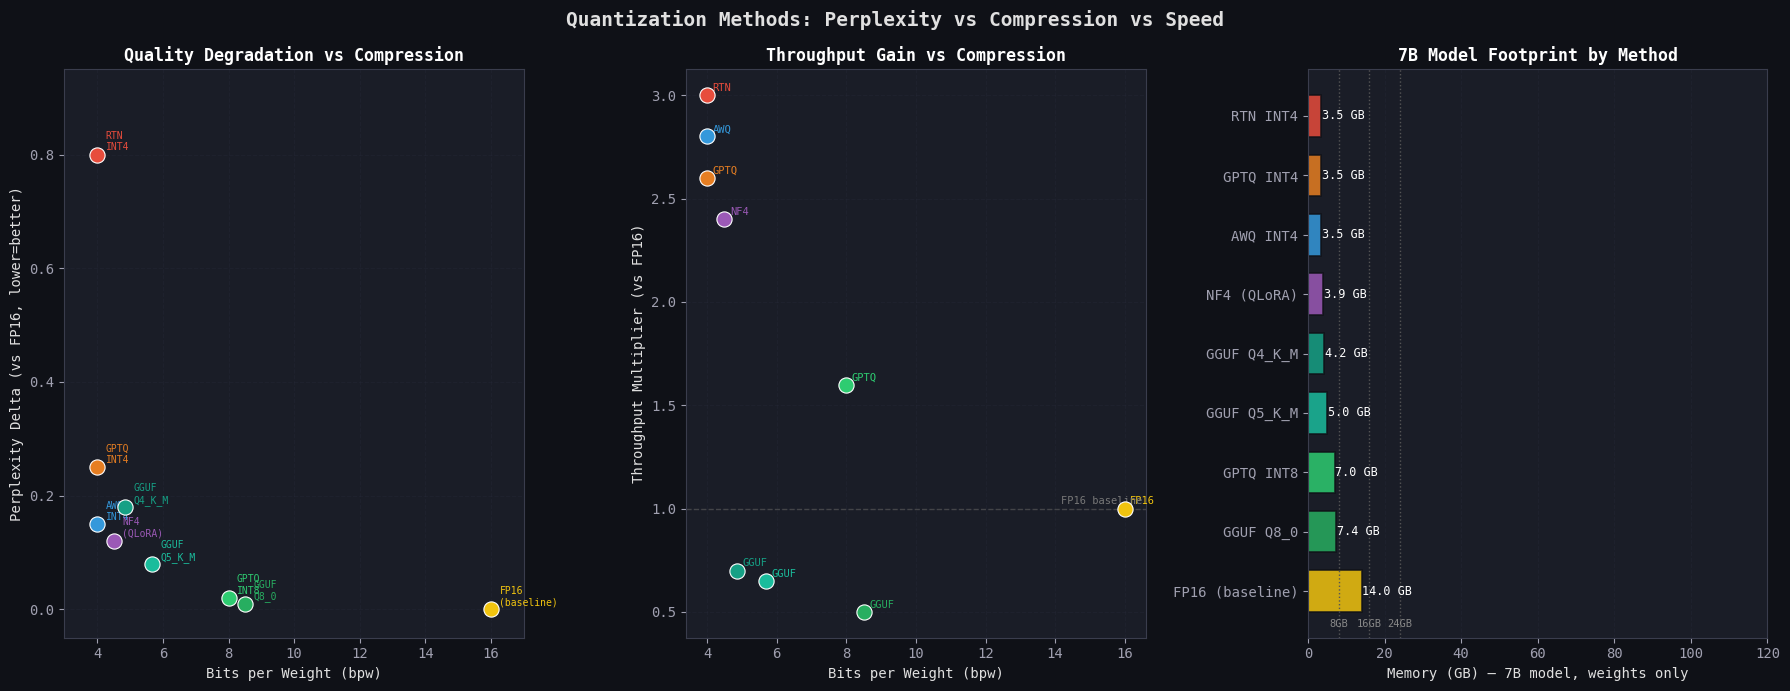


Key decision guide:
  GPU inference  →  AWQ INT4 (best quality) or GPTQ INT4 (widest support)
  CPU/Mac        →  GGUF Q5_K_M (great balance) or Q4_K_M (speed-first)
  Fine-tuning    →  QLoRA (NF4 + DQ) via bitsandbytes + PEFT
  Production API →  vLLM with AWQ/GPTQ, or FP8 on H100


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8 · Quantization methods comparison + practical guide
# ─────────────────────────────────────────────────────────────────────────────

# Curated benchmark data (representative, from published papers/community evals)
quant_methods = {
    'FP16 (baseline)': {'bpw': 16.0,  'perplexity_delta': 0.00, 'throughput_x': 1.0,  'color': C['bf16']},
    'GPTQ INT8':       {'bpw': 8.0,   'perplexity_delta': 0.02, 'throughput_x': 1.6,  'color': C['int8']},
    'AWQ INT4':        {'bpw': 4.0,   'perplexity_delta': 0.15, 'throughput_x': 2.8,  'color': C['nf4']},
    'GPTQ INT4':       {'bpw': 4.0,   'perplexity_delta': 0.25, 'throughput_x': 2.6,  'color': '#e67e22'},
    'NF4 (QLoRA)':     {'bpw': 4.5,   'perplexity_delta': 0.12, 'throughput_x': 2.4,  'color': C['dq']},
    'GGUF Q4_K_M':     {'bpw': 4.85,  'perplexity_delta': 0.18, 'throughput_x': 0.7,  'color': '#16a085'},
    'GGUF Q5_K_M':     {'bpw': 5.68,  'perplexity_delta': 0.08, 'throughput_x': 0.65, 'color': '#1abc9c'},
    'GGUF Q8_0':       {'bpw': 8.5,   'perplexity_delta': 0.01, 'throughput_x': 0.5,  'color': '#27ae60'},
    'RTN INT4':        {'bpw': 4.0,   'perplexity_delta': 0.80, 'throughput_x': 3.0,  'color': C['fp32']},
}

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Quantization Methods: Perplexity vs Compression vs Speed', fontsize=14, fontweight='bold')

names = list(quant_methods.keys())
bpws  = [v['bpw'] for v in quant_methods.values()]
ppls  = [v['perplexity_delta'] for v in quant_methods.values()]
thrps = [v['throughput_x'] for v in quant_methods.values()]
clrs  = [v['color'] for v in quant_methods.values()]

# ─ Left: perplexity degradation vs bpw ─
ax = axes[0]
for name, bpw, ppl, clr in zip(names, bpws, ppls, clrs):
    ax.scatter(bpw, ppl, color=clr, s=120, zorder=5, edgecolors='white', linewidth=0.8)
    ax.annotate(name.replace(' ', '\n'), (bpw, ppl),
                textcoords='offset points', xytext=(6, 3), fontsize=7, color=clr)
ax.set_xlabel('Bits per Weight (bpw)')
ax.set_ylabel('Perplexity Delta (vs FP16, lower=better)')
ax.set_title('Quality Degradation vs Compression', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim(3, 17)
ax.set_ylim(-0.05, 0.95)

# ─ Middle: throughput vs bpw ─
ax2 = axes[1]
for name, bpw, thr, clr in zip(names, bpws, thrps, clrs):
    ax2.scatter(bpw, thr, color=clr, s=120, zorder=5, edgecolors='white', linewidth=0.8)
    ax2.annotate(name.split(' ')[0], (bpw, thr),
                 textcoords='offset points', xytext=(4, 3), fontsize=7.5, color=clr)
ax2.axhline(1.0, color='#555', linestyle='--', linewidth=1, alpha=0.7)
ax2.text(16.5, 1.02, 'FP16 baseline', color='#777', fontsize=7.5, ha='right')
ax2.set_xlabel('Bits per Weight (bpw)')
ax2.set_ylabel('Throughput Multiplier (vs FP16)')
ax2.set_title('Throughput Gain vs Compression', fontweight='bold')
ax2.grid(True, alpha=0.3)

# ─ Right: memory footprint for 7B model ─
ax3 = axes[2]
mem_7b = [b * 7e9 / 8 / 1e9 for b in bpws]
sorted_data = sorted(zip(names, mem_7b, clrs), key=lambda x: x[1], reverse=True)
snames, smems, sclrs = zip(*sorted_data)
bars = ax3.barh(snames, smems, color=sclrs, alpha=0.85, edgecolor='#0f1117', linewidth=1.2, height=0.7)
for bar, val in zip(bars, smems):
    ax3.text(val + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val:.1f} GB', va='center', fontsize=8.5, color='white')
for vram in [8, 16, 24]:
    ax3.axvline(vram, color='#555', linestyle=':', linewidth=1)
    ax3.text(vram, -0.6, f'{vram}GB', ha='center', fontsize=7.5, color='#888')
ax3.set_xlabel('Memory (GB) — 7B model, weights only')
ax3.set_title('7B Model Footprint by Method', fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')
ax3.set_xlim(0, 120)

plt.tight_layout()
plt.savefig('methods_landscape.png', dpi=140, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print('\nKey decision guide:')
print('  GPU inference  →  AWQ INT4 (best quality) or GPTQ INT4 (widest support)')
print('  CPU/Mac        →  GGUF Q5_K_M (great balance) or Q4_K_M (speed-first)')
print('  Fine-tuning    →  QLoRA (NF4 + DQ) via bitsandbytes + PEFT')
print('  Production API →  vLLM with AWQ/GPTQ, or FP8 on H100')

---
## Part 9 — Reusable `ModelMemoryCalculator`

A production-ready utility class capturing everything from this notebook.

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9 · Production-ready ModelMemoryCalculator
# ─────────────────────────────────────────────────────────────────────────────

class ModelMemoryCalculator:
    """
    Comprehensive GPU memory estimator for LLMs and SLMs.

    Covers:
    - Weight memory across dtypes (FP32/BF16/INT8/NF4 with DQ)
    - KV cache for any architecture (supports GQA/MQA)
    - Training budget (optimizer states, gradients, activations)
    - Hardware fit checks against common GPU SKUs

    Usage:
        calc = ModelMemoryCalculator('Mistral 7B')
        calc.report(seq_len=8192)
    """

    DTYPE_BITS = {
        'fp32': 32, 'fp16': 16, 'bf16': 16,
        'int8': 8,  'int4': 4,  'nf4': 4.5,  # NF4+DQ effective
        'fp8':  8,  'int2': 2,
    }

    GPU_VRAM = {
        'RTX 3060':   12, 'RTX 3070':  8,  'RTX 3080':  10, 'RTX 3090': 24,
        'RTX 4070':   12, 'RTX 4090':  24,
        'A10G':       24, 'A100 40GB': 40, 'A100 80GB': 80,
        'H100 80GB':  80, 'H100 SXM':  80, 'MI300X':   192,
        'M2 Ultra':  192, 'M3 Max':    128,
    }

    def __init__(self, model_name: str = None, n_params: float = None,
                 n_layers: int = 32, n_heads: int = 32, n_kv_heads: int = None,
                 d_model: int = 4096, d_head: int = 128):
        if model_name and model_name in MODEL_CONFIGS:
            cfg = MODEL_CONFIGS[model_name]
            self.n_params    = cfg['params']
            self.n_layers    = cfg['layers']
            self.n_heads     = cfg['n_heads']
            self.n_kv_heads  = cfg['n_kv_heads']
            self.d_model     = cfg['d_model']
            self.d_head      = cfg['d_head']
            self.name        = model_name
        else:
            self.n_params    = n_params
            self.n_layers    = n_layers
            self.n_heads     = n_heads
            self.n_kv_heads  = n_kv_heads or n_heads
            self.d_model     = d_model
            self.d_head      = d_head
            self.name        = f'Custom ({n_params/1e9:.1f}B)' if n_params else 'Custom'

    def weight_memory_gb(self, dtype: str = 'bf16') -> float:
        bits = self.DTYPE_BITS[dtype.lower()]
        return self.n_params * bits / 8 / 1e9

    def kv_cache_gb(self, seq_len: int, batch_size: int = 1, dtype: str = 'bf16') -> float:
        bits = self.DTYPE_BITS[dtype.lower()]
        return (2 * self.n_layers * self.n_kv_heads * self.d_head
                * seq_len * batch_size * bits / 8) / 1e9

    def inference_gb(self, dtype: str = 'bf16', seq_len: int = 2048,
                     batch_size: int = 1, kv_dtype: str = 'bf16') -> dict:
        w = self.weight_memory_gb(dtype)
        k = self.kv_cache_gb(seq_len, batch_size, kv_dtype)
        return {'weights': w, 'kv_cache': k, 'total': w + k}

    def training_gb(self, dtype: str = 'bf16', seq_len: int = 2048,
                    batch_size: int = 1, optimizer: str = 'adam',
                    gradient_checkpointing: bool = False) -> dict:
        dtype_bits = self.DTYPE_BITS[dtype.lower()]
        w = self.weight_memory_gb(dtype)
        # Adam: 2 FP32 states; SGD: 1 FP32 state; Adafactor: ~0.5
        opt_mult = {'adam': 2, 'sgd': 1, 'adafactor': 0.5}.get(optimizer, 2)
        opt = self.n_params * 4 * opt_mult / 1e9
        grad = self.n_params * dtype_bits / 8 / 1e9
        # Activations: simplified estimate
        act_scale = 0.1 if gradient_checkpointing else 1.0
        act = (batch_size * seq_len * self.d_model * self.n_layers * 2 * 2 * act_scale) / 1e9
        kv  = self.kv_cache_gb(seq_len, batch_size)
        return {'weights': w, 'optimizer': opt, 'gradients': grad,
                'activations': act, 'kv_cache': kv, 'total': w + opt + grad + act + kv}

    def gpu_fit_check(self, budget_gb: float) -> dict:
        fits = {gpu: vram for gpu, vram in self.GPU_VRAM.items() if vram >= budget_gb * 1.1}
        tight = {gpu: vram for gpu, vram in self.GPU_VRAM.items()
                 if budget_gb <= vram < budget_gb * 1.1}
        return {'fits': fits, 'tight': tight}

    def report(self, seq_len: int = 2048, batch_size: int = 1):
        print(f'{'='*62}')
        print(f'  Memory Report: {self.name}')
        print(f'  Params: {self.n_params/1e9:.2f}B | Layers: {self.n_layers} | '
              f'd_model: {self.d_model} | KV heads: {self.n_kv_heads}')
        print(f'{'='*62}')

        print('\n── Inference (seq={:,}, batch={}) ──'.format(seq_len, batch_size))
        print(f"  {'Dtype':<12} {'Weights':>10} {'KV Cache':>10} {'Total':>10} {'Fit on'}")
        print(f"  {'─'*65}")
        for dtype in ['fp32', 'bf16', 'int8', 'nf4']:
            bud = self.inference_gb(dtype, seq_len, batch_size)
            gpus = self.gpu_fit_check(bud['total'])
            smallest = min(gpus['fits'].values()) if gpus['fits'] else None
            gpu_str = f">= {smallest}GB GPU" if smallest else '❌ needs multi-GPU'
            print(f"  {dtype.upper():<12} {bud['weights']:>9.2f}G {bud['kv_cache']:>9.2f}G "
                  f"{bud['total']:>9.2f}G  {gpu_str}")

        print('\n── Training BF16 (seq={:,}, batch={}, Adam) ──'.format(seq_len, batch_size))
        bud = self.training_gb('bf16', seq_len, batch_size)
        bud_ckpt = self.training_gb('bf16', seq_len, batch_size, gradient_checkpointing=True)
        print(f"  {'Component':<20} {'Full':>12} {'+ Grad Ckpt':>14}")
        print(f"  {'─'*50}")
        for k in ['weights', 'optimizer', 'gradients', 'activations', 'kv_cache', 'total']:
            flag = '◀ TOTAL' if k == 'total' else ''
            print(f"  {k:<20} {bud[k]:>10.2f}G  {bud_ckpt[k]:>12.2f}G  {flag}")


# Demo
calc = ModelMemoryCalculator('Mistral 7B')
calc.report(seq_len=8192, batch_size=1)

  Memory Report: Mistral 7B
  Params: 7.24B | Layers: 32 | d_model: 4096 | KV heads: 8

── Inference (seq=8,192, batch=1) ──
  Dtype           Weights   KV Cache      Total Fit on
  ─────────────────────────────────────────────────────────────────
  FP32             28.96G      1.07G     30.03G  >= 40GB GPU
  BF16             14.48G      1.07G     15.55G  >= 24GB GPU
  INT8              7.24G      1.07G      8.31G  >= 10GB GPU
  NF4               4.07G      1.07G      5.15G  >= 8GB GPU

── Training BF16 (seq=8,192, batch=1, Adam) ──
  Component                    Full    + Grad Ckpt
  ──────────────────────────────────────────────────
  weights                   14.48G         14.48G  
  optimizer                 57.92G         57.92G  
  gradients                 14.48G         14.48G  
  activations                4.29G          0.43G  
  kv_cache                   1.07G          1.07G  
  total                     92.25G         88.38G  ◀ TOTAL


In [21]:
# Try with a custom model (e.g., your own architecture)
custom = ModelMemoryCalculator(
    n_params=13e9, n_layers=40, n_heads=40, n_kv_heads=8,
    d_model=5120, d_head=128
)
custom.report(seq_len=4096, batch_size=2)

  Memory Report: Custom (13.0B)
  Params: 13.00B | Layers: 40 | d_model: 5120 | KV heads: 8

── Inference (seq=4,096, batch=2) ──
  Dtype           Weights   KV Cache      Total Fit on
  ─────────────────────────────────────────────────────────────────
  FP32             52.00G      1.34G     53.34G  >= 80GB GPU
  BF16             26.00G      1.34G     27.34G  >= 40GB GPU
  INT8             13.00G      1.34G     14.34G  >= 24GB GPU
  NF4               7.31G      1.34G      8.65G  >= 10GB GPU

── Training BF16 (seq=4,096, batch=2, Adam) ──
  Component                    Full    + Grad Ckpt
  ──────────────────────────────────────────────────
  weights                   26.00G         26.00G  
  optimizer                104.00G        104.00G  
  gradients                 26.00G         26.00G  
  activations                6.71G          0.67G  
  kv_cache                   1.34G          1.34G  
  total                    164.05G        158.01G  ◀ TOTAL


---
## Part 10 — Mixed Precision Training: The Full Picture

Modern training runs use **multiple precision levels simultaneously**:

```
Master weights   ──── FP32  (optimizer states, gradient accumulation)
Forward pass     ──── BF16  (fast tensor cores, same dynamic range as FP32)
Backward pass    ──── BF16  (gradients in BF16)
Gradient update  ──── FP32  (precision for small updates matters)
```

**FP8 training** (introduced on H100, used in DeepSeek V3/Llama 4):
- Forward + backward in FP8
- Requires **dynamic scaling** (per-tensor or per-tile scaling factors)
- Enables ~2× memory saving over BF16 on activations
- DeepSeek V3 uses fine-grained FP8 with tile-level scaling to avoid outlier collapse

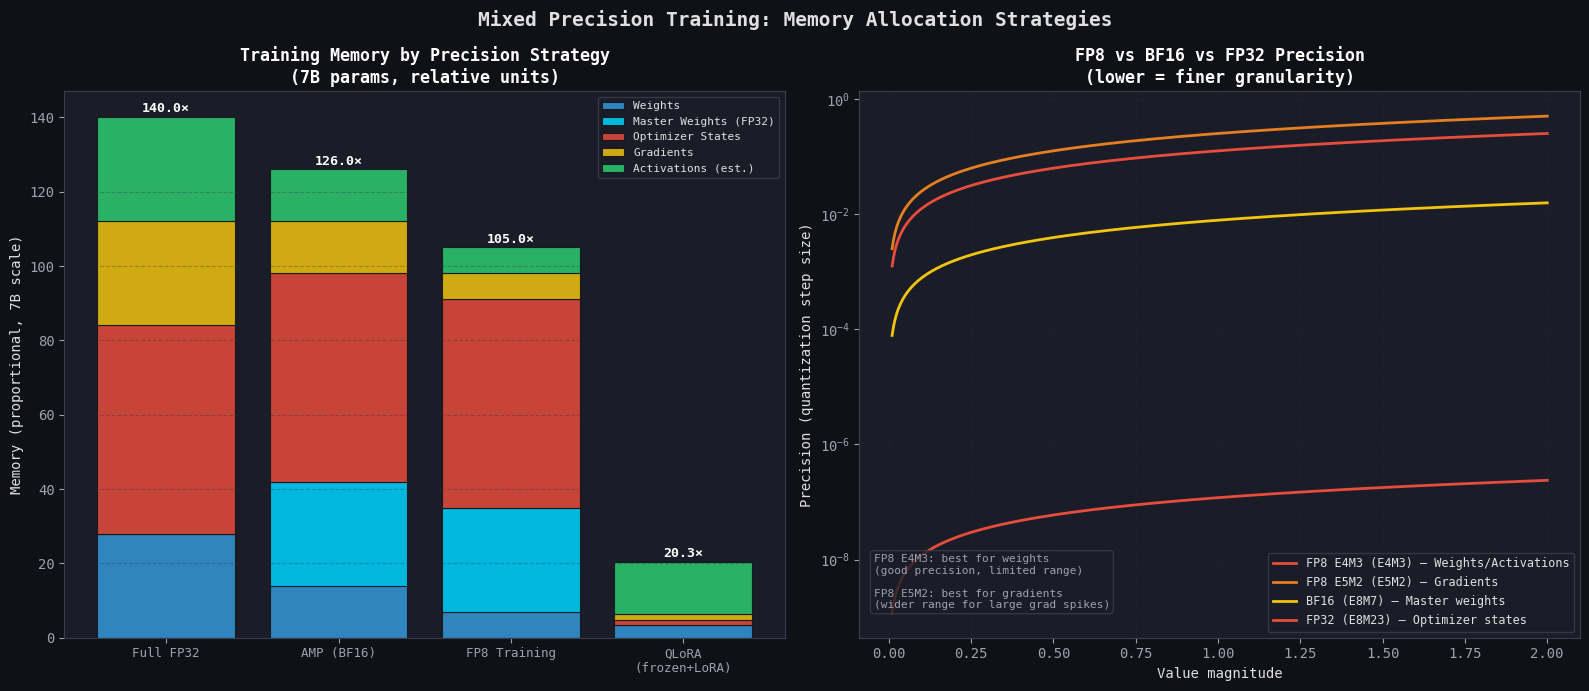


── Mixed Precision Training Quick Reference ──
  AMP (BF16):    Standard on A100/H100. ~3× more memory than naive FP32 accounting.
  FP8 Training:  H100 SXM only (currently). Used in DeepSeek V3, Llama 4.
  QLoRA:         Best for consumer GPU fine-tuning. 7B fine-tune on 16GB RTX 4080.
  Full FP32:     Avoid. Only for debugging numerical issues.


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 10 · Mixed precision training summary + FP8 analysis
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Mixed Precision Training: Memory Allocation Strategies', fontsize=14, fontweight='bold')

# ─ Left: memory breakdown for different training precision strategies ─
ax = axes[0]

strategies = {
    'Full FP32': {
        'weights': 4, 'master_w': 0, 'optimizer': 8, 'gradients': 4, 'activations': 4,
        'desc': 'Everything FP32'
    },
    'AMP (BF16)': {
        'weights': 2, 'master_w': 4, 'optimizer': 8, 'gradients': 2, 'activations': 2,
        'desc': 'BF16 compute, FP32 master'
    },
    'FP8 Training': {
        'weights': 1, 'master_w': 4, 'optimizer': 8, 'gradients': 1, 'activations': 1,
        'desc': 'FP8 compute, FP32 master'
    },
    'QLoRA\n(frozen+LoRA)': {
        'weights': 0.5, 'master_w': 0, 'optimizer': 0.2, 'gradients': 0.2, 'activations': 2,
        'desc': 'NF4 base + BF16 LoRA'
    },
}

# Scale by 7B params for illustration
P_ref = 7e9 / 1e9  # 7 units
components = ['weights', 'master_w', 'optimizer', 'gradients', 'activations']
comp_colors = [C['nf4'], C['accent'], C['fp32'], C['bf16'], C['int8']]
comp_labels = ['Weights', 'Master Weights (FP32)', 'Optimizer States', 'Gradients', 'Activations (est.)']

x  = np.arange(len(strategies))
bottom = np.zeros(len(strategies))
for comp, clr, lbl in zip(components, comp_colors, comp_labels):
    vals = np.array([s[comp] * P_ref for s in strategies.values()])
    ax.bar(x, vals, bottom=bottom, label=lbl, color=clr, alpha=0.85,
           edgecolor='#0f1117', linewidth=0.8)
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(list(strategies.keys()), fontsize=9)
ax.set_ylabel('Memory (proportional, 7B scale)')
ax.set_title('Training Memory by Precision Strategy\n(7B params, relative units)', fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

# Add total labels
for xi, tot in zip(x, bottom):
    ax.text(xi, tot + 0.5, f'{tot:.1f}×', ha='center', va='bottom', fontsize=9.5, color='white', fontweight='bold')

# ─ Right: FP8 vs BF16 precision on weight-like data ─
ax2 = axes[1]

# FP8 E4M3 format: 4 exp bits, 3 mantissa bits
# FP8 E5M2 format: 5 exp bits, 2 mantissa bits
fp8_formats = {
    'FP8 E4M3': {'exp': 4, 'mant': 3, 'color': '#e74c3c', 'use': 'Weights/Activations'},
    'FP8 E5M2': {'exp': 5, 'mant': 2, 'color': '#e67e22', 'use': 'Gradients'},
    'BF16':     {'exp': 8, 'mant': 7, 'color': C['bf16'],  'use': 'Master weights'},
    'FP32':     {'exp': 8, 'mant': 23,'color': C['fp32'],  'use': 'Optimizer states'},
}

# Precision staircase comparison
x_vals = np.linspace(0.01, 2.0, 1000)
for fname, f in fp8_formats.items():
    # Representable precision (step size) at each value
    if f['exp'] > 0:
        step = x_vals * 2**(-f['mant'])
    else:
        step = np.ones_like(x_vals) / (2**f['mant'])
    ax2.semilogy(x_vals, step, color=f['color'], linewidth=2,
                 label=f"{fname} (E{f['exp']}M{f['mant']}) — {f['use']}")

ax2.set_xlabel('Value magnitude')
ax2.set_ylabel('Precision (quantization step size)')
ax2.set_title('FP8 vs BF16 vs FP32 Precision\n(lower = finer granularity)', fontweight='bold')
ax2.legend(fontsize=8.5)
ax2.grid(True, alpha=0.3)
ax2.text(0.02, 0.05, 'FP8 E4M3: best for weights\n(good precision, limited range)\n\n'
         'FP8 E5M2: best for gradients\n(wider range for large grad spikes)',
         transform=ax2.transAxes, va='bottom', fontsize=8, color='#a0a0b0',
         bbox=dict(boxstyle='round,pad=0.3', fc='#1a1d27', ec='#3a3d4d', alpha=0.8))

plt.tight_layout()
plt.savefig('mixed_precision.png', dpi=140, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print('\n── Mixed Precision Training Quick Reference ──')
print('  AMP (BF16):    Standard on A100/H100. ~3× more memory than naive FP32 accounting.')
print('  FP8 Training:  H100 SXM only (currently). Used in DeepSeek V3, Llama 4.')
print('  QLoRA:         Best for consumer GPU fine-tuning. 7B fine-tune on 16GB RTX 4080.')
print('  Full FP32:     Avoid. Only for debugging numerical issues.')

---
## Summary — The Complete Picture

### Format Hierarchy
```
FP32  (32b)  ──  Reference quality. Training optimizer states.
BF16  (16b)  ──  Training standard. Same range as FP32, less mantissa.
FP16  (16b)  ──  Older inference standard. Overflow risk in training.
INT8   (8b)  ──  Near-lossless inference. GPTQ INT8 / bitsandbytes.
NF4   (~4.5b)── QLoRA default. Optimal for Gaussian weights.
GPTQ INT4 (4b)─ Hessian-guided. High quality GPU inference.
AWQ INT4  (4b)─ Salient-weight protection. Best quality at 4-bit.
GGUF Q4   (4.x)─ CPU/Metal. Mixed precision blocks. llama.cpp.
FP8    (8b)  ──  H100 training. E4M3 for weights, E5M2 for grads.
```

### The 20% Rule
Always budget **+20% GPU overhead** beyond model memory for:
- CUDA kernels and framework overhead
- Temporary buffers during matmul
- Fragmentation

### Decision Flowchart
```
Do you have an H100?  →  FP8 training, BF16 inference
A100 80GB?            →  BF16 training, INT8/AWQ inference
RTX 4090 (24GB)?      →  QLoRA fine-tune, GPTQ/AWQ INT4 inference
RTX 3080 (10GB)?      →  GGUF Q4_K_M, models ≤7B
Mac M-series?         →  GGUF Q5_K_M (unified memory = great value)
Multi-GPU?            →  Tensor parallel + BF16; quantize only if VRAM-bound
```

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# FINAL CELL · Interactive model sizing tool
# ─────────────────────────────────────────────────────────────────────────────

def size_my_model(model_name_or_params, seq_len=2048, batch_size=1, your_gpu_gb=None):
    """
    Quick sizing function. Pass a known model name or parameter count in billions.

    Examples:
        size_my_model('Mistral 7B', seq_len=32768)
        size_my_model(13e9, seq_len=4096, your_gpu_gb=24)
    """
    if isinstance(model_name_or_params, str):
        calc = ModelMemoryCalculator(model_name_or_params)
    else:
        calc = ModelMemoryCalculator(n_params=model_name_or_params,
                                     n_layers=32, n_heads=32, n_kv_heads=8,
                                     d_model=4096, d_head=128)
    print(f"\n{'─'*60}")
    print(f'  Quick Size Guide: {calc.name}')
    print(f'  seq_len={seq_len:,}  batch={batch_size}')
    if your_gpu_gb:
        print(f'  Your GPU: {your_gpu_gb}GB')
    print(f"{'─'*60}")

    print(f"\n  {'Dtype':<12} {'Total GB':>10} {'Fits?':>10}")
    print(f"  {'─'*35}")
    for dtype in ['fp32', 'bf16', 'int8', 'nf4', 'int4']:
        bud = calc.inference_gb(dtype, seq_len, batch_size)
        total = bud['total']
        if your_gpu_gb:
            fits = '✅ YES' if total * 1.2 <= your_gpu_gb else '❌ NO'
        else:
            fits = ''
        print(f"  {dtype.upper():<12} {total:>9.2f}G {fits:>10}")

    print(f"\n  KV cache at seq={seq_len:,} (BF16): {calc.kv_cache_gb(seq_len, batch_size):.2f} GB")


# Try it:
size_my_model('LLaMA-3 8B', seq_len=32768, your_gpu_gb=24)
print()
size_my_model('LLaMA-3 70B', seq_len=8192, your_gpu_gb=80)

print('\n' + '='*60)
print('  Notebook complete. Key classes to keep:')
print('  · LinearQuantizer    — symmetric/asymmetric INT quantization')
print('  · BlockwiseQuantizer — absmax block-wise (bitsandbytes-style)')
print('  · NF4Quantizer       — quantile codebook for Gaussian weights')
print('  · DoubleQuantizer    — NF4 + INT8 scale quantization (QLoRA)')
print('  · ModelMemoryCalculator — full budget: weights + KV + training')
print('='*60)


────────────────────────────────────────────────────────────
  Quick Size Guide: LLaMA-3 8B
  seq_len=32,768  batch=1
  Your GPU: 24GB
────────────────────────────────────────────────────────────

  Dtype          Total GB      Fits?
  ───────────────────────────────────
  FP32             36.41G       ❌ NO
  BF16             20.35G       ❌ NO
  INT8             12.32G      ✅ YES
  NF4               8.81G      ✅ YES
  INT4              8.31G      ✅ YES

  KV cache at seq=32,768 (BF16): 4.29 GB


────────────────────────────────────────────────────────────
  Quick Size Guide: LLaMA-3 70B
  seq_len=8,192  batch=1
  Your GPU: 80GB
────────────────────────────────────────────────────────────

  Dtype          Total GB      Fits?
  ───────────────────────────────────
  FP32            285.08G       ❌ NO
  BF16            143.88G       ❌ NO
  INT8             73.28G       ❌ NO
  NF4              42.40G      ✅ YES
  INT4             37.98G      ✅ YES

  KV cache at seq=8,192 (BF16): 2.68 GB


: 